#📌 RETO 1: Extracción de datos

## Cargar datos desde API JSON de TelecomX

In [71]:
import pandas as pd


# URL del archivo JSON en GitHub (versión raw)

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"


# Cargar los datos directamente desde la URL en un DataFrame de pandas

df = pd.read_json(url)


# Vista rápida de los datos cargados
df.head()



,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [72]:
import pandas as pd  # por si ejecutas esta celda sola

# df viene de la sección de Extracción
df_flat = pd.json_normalize(df.to_dict(orient='records'), sep='.')

# Mostrar todas las columnas del DataFrame aplanado
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_flat.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [73]:
df_flat.to_excel('df_flat.xlsx', index=False)

#🔧 Transformación

In [74]:
# 01. Transformación de datos

## 1.1 Convertir el JSON a una tabla plana (similar a cargar un CSV)
df_flat = pd.json_normalize(df.to_dict(orient="records"))

## 1.2 Exploración inicial (replicando lógica de inmuebles_cdmx)
df_flat.sample(5)





,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
6384,8774-GSBUN,No,Male,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.40,1797.1
7160,9844-FELAJ,No,Female,1,Yes,Yes,70,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,107.90,7475.85
1460,2091-GPPIQ,No,Female,0,Yes,Yes,72,Yes,Yes,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Electronic check,78.95,5730.15
2494,3485-REZCX,,Male,0,No,No,64,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,No,One year,Yes,Credit card (automatic),84.30,5289.05
6397,8780-YRMTT,No,Female,0,No,No,66,No,No phone service,DSL,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Mailed check,47.40,3177.25


In [75]:
## 1.3 Revisar la estructura del DataFrame
df_flat.shape



(7267, 21)

In [76]:
## 1.4 Ver las columnas del DataFrame
df_flat.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [77]:
## 1.5 Información del DataFrame
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [78]:
# 02. Comprobación de datos

## 2.1 Tratamiento de datos nulos. Matriz booleana de valores nulos
df_flat.isnull()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7263,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7264,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7265,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [79]:
### 2.1.1 Conteo de valores nulos por columna
df_flat.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [80]:
### 2.1.2 Rellenar valores nulos con 0
df_flat.fillna(0)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [81]:
### 2.1.3 Asignar el DataFrame con valores nulos rellenados
df_flat = df_flat.fillna(0)
df_flat.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [82]:
### 2.1.4 Convertir columna account.Charges.Total a tipo numérico
# La columna se lee como object (texto), necesita convertirse a float
df_flat['account.Charges.Total'] = pd.to_numeric(df_flat['account.Charges.Total'], errors='coerce')

# Verificar que la conversión fue exitosa
print("Tipo de datos de account.Charges.Total:", df_flat['account.Charges.Total'].dtype)
print("Primeros valores:", df_flat['account.Charges.Total'].head())

Tipo de datos de account.Charges.Total: float64
Primeros valores: 0     593.30
1     542.40
2     280.85
3    1237.85
4     267.40
Name: account.Charges.Total, dtype: float64


In [83]:
### 2.1.5 Convertir columna account.Charges.Monthly a tipo numérico
# Asegurar que también sea numérica para análisis estadístico
df_flat['account.Charges.Monthly'] = pd.to_numeric(df_flat['account.Charges.Monthly'], errors='coerce')

# Verificar ambas columnas de cargos
print("\nTipos de datos de las columnas de cargos:")
print("account.Charges.Monthly:", df_flat['account.Charges.Monthly'].dtype)
print("account.Charges.Total:", df_flat['account.Charges.Total'].dtype)


Tipos de datos de las columnas de cargos:
account.Charges.Monthly: float64
account.Charges.Total: float64


In [84]:
## 2.2 Identificar filas duplicadas (todas las columnas iguales)
df_flat.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7262,False
7263,False
7264,False
7265,False


In [85]:
### 2.2.1 Contar el número de filas duplicadas
df_flat.duplicated().sum()

np.int64(0)

In [86]:
### 2.2.2 Ver las filas duplicadas (si existen)
df_flat[df_flat.duplicated()]


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


In [87]:
### 2.2.3 Obtener los índices de las filas duplicadas
df_flat[df_flat.duplicated()].index

Index([], dtype='int64')

In [88]:
## 2.3 Revisar valores únicos de columnas categóricas

# Valores únicos de 'Churn'
df_flat['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [89]:
### 2.3.1 Distribución de frecuencias de 'Churn'
df_flat['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869
,224


In [90]:
### 2.3.2 Valores únicos de 'customer.gender'
df_flat['customer.gender'].unique()

array(['Female', 'Male'], dtype=object)

In [91]:
### 2.3.3 Distribución de frecuencias de 'customer.gender'
df_flat['customer.gender'].value_counts()


,count
customer.gender,
Male,3675
Female,3592


In [92]:
### 2.3.4 Valores únicos de 'internet.InternetService'
df_flat['internet.InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [93]:
### 2.3.5 Distribución de frecuencias de 'internet.InternetService'
df_flat['internet.InternetService'].value_counts()

,count
internet.InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [94]:
### 2.3.6 Valores únicos de 'account.Contract'
df_flat['account.Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [95]:
### 2.3.7  Distribución de frecuencias de 'account.Contract'
df_flat['account.Contract'].value_counts()

,count
account.Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [96]:
 ## 2.4 Remover registros inconsistentes

### 2.4.1 Buscar valores que podrían ser inconsistentes
df_flat.query('`customer.tenure` == 0')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [97]:
### 2.4.2 Obtener índices de registros inconsistentes (replicando lógica de inmuebles)
df_flat.query('`customer.tenure` == 0').index

Index([975, 1775, 1955, 2075, 2232, 2308, 2930, 3134, 3203, 4169, 5599], dtype='int64')

In [98]:
# 03. Columna de cuentas diarias (Opcional)

## 3.1 Verificar las dimensiones del DataFrame
df_flat.shape


(7267, 21)

In [99]:
## 3.2  Crear columna Cuentas_Diarias. Facturación mensual dividida entre 30 días
df_flat['Cuentas_Diarias'] = df_flat['account.Charges.Monthly'] / 30
df_flat.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [100]:
## 3.3 Ver las últimas filas del DataFrame con la nueva columna
df_flat.tail()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.60,1.966667


In [101]:
## 3.4 Verificar las columnas relevantes: facturación mensual y cuentas diarias
df_flat[['account.Charges.Monthly', 'Cuentas_Diarias']].head(10)

,account.Charges.Monthly,Cuentas_Diarias
0,65.60,2.186667
1,59.90,1.996667
2,73.90,2.463333
3,98.00,3.266667
4,83.90,2.796667
5,69.40,2.313333
6,109.70,3.656667
7,84.65,2.821667
8,48.20,1.606667
9,90.45,3.015000


In [102]:
## 3.5 Estadísticas descriptivas de Cuentas_Diarias
print("Valor mínimo de Cuentas_Diarias:", df_flat['Cuentas_Diarias'].min())
print("Valor máximo de Cuentas_Diarias:", df_flat['Cuentas_Diarias'].max())
print("Valor promedio de Cuentas_Diarias:", df_flat['Cuentas_Diarias'].mean())

Valor mínimo de Cuentas_Diarias: 0.6083333333333333
Valor máximo de Cuentas_Diarias: 3.9583333333333335
Valor promedio de Cuentas_Diarias: 2.1573365900646757


In [103]:
# 04. Estandarización y transformación de datos. Conversión de valores textuales a binarios.

## 4.1 Convertir "Yes"/"No" en 1/0

### 4.1.1 Convertir 'Churn' de Yes/No a 1/0
df_flat['Churn_Binario'] = df_flat['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df_flat[['Churn', 'Churn_Binario']].head()


,Churn,Churn_Binario
0,No,0
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1


In [104]:
### 4.1.2 Convertir 'customer.Partner' de Yes/No a 1/0
df_flat['Tiene_Pareja'] = df_flat['customer.Partner'].apply(lambda x: 1 if x == 'Yes' else 0)
df_flat[['customer.Partner', 'Tiene_Pareja']].head()

,customer.Partner,Tiene_Pareja
0,Yes,1
1,No,0
2,No,0
3,Yes,1
4,Yes,1


In [105]:
### 4.1.3 Convertir 'customer.Dependents' de Yes/No a 1/0
df_flat['Tiene_Dependientes'] = df_flat['customer.Dependents'].apply(lambda x: 1 if x == 'Yes' else 0)
df_flat[['customer.Dependents', 'Tiene_Dependientes']].head()

,customer.Dependents,Tiene_Dependientes
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


In [106]:
### 4.1.4 Convertir 'account.PaperlessBilling' de Yes/No a 1/0
df_flat['Facturacion_Sin_Papel'] = df_flat['account.PaperlessBilling'].apply(lambda x: 1 if x == 'Yes' else 0)
df_flat[['account.PaperlessBilling', 'Facturacion_Sin_Papel']].head()

,account.PaperlessBilling,Facturacion_Sin_Papel
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1


In [107]:
## 4.2 Traducción de valores categóricos. Traducir valores del inglés al español

### 4.2.1 Traducir 'customer.gender' de Male/Female a Masculino/Femenino
df_flat['Genero'] = df_flat['customer.gender'].apply(lambda x: 'Masculino' if x == 'Male' else 'Femenino')
df_flat[['customer.gender', 'Genero']].head()

,customer.gender,Genero
0,Female,Femenino
1,Male,Masculino
2,Male,Masculino
3,Male,Masculino
4,Female,Femenino


In [108]:
### 4.2.2 Traducir 'internet.InternetService' al español
def traducir_internet(valor):
    if valor == 'DSL':
        return 'DSL'
    elif valor == 'Fiber optic':
        return 'Fibra óptica'
    else:
        return 'Sin servicio'

df_flat['Servicio_Internet'] = df_flat['internet.InternetService'].apply(traducir_internet)
df_flat[['internet.InternetService', 'Servicio_Internet']].head()


,internet.InternetService,Servicio_Internet
0,DSL,DSL
1,DSL,DSL
2,Fiber optic,Fibra óptica
3,Fiber optic,Fibra óptica
4,Fiber optic,Fibra óptica


In [109]:
### 4.2.3 Traducir 'account.Contract' al español
def traducir_contrato(valor):
    if valor == 'Month-to-month':
        return 'Mes a mes'
    elif valor == 'One year':
        return 'Un año'
    elif valor == 'Two year':
        return 'Dos años'
    else:
        return valor

df_flat['Tipo_Contrato'] = df_flat['account.Contract'].apply(traducir_contrato)
df_flat[['account.Contract', 'Tipo_Contrato']].head()

,account.Contract,Tipo_Contrato
0,One year,Un año
1,Month-to-month,Mes a mes
2,Month-to-month,Mes a mes
3,Month-to-month,Mes a mes
4,Month-to-month,Mes a mes


In [110]:
## 4.3 Renombrado de columnas clave. Renombrar columnas del inglés al español para mejor comprensión.

### 4.3.1 Verificar qué columnas necesitan ser renombradas
print("Columnas actuales del DataFrame:")
print(df_flat.columns.tolist())


Columnas actuales del DataFrame:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'Churn_Binario', 'Tiene_Pareja', 'Tiene_Dependientes', 'Facturacion_Sin_Papel', 'Genero', 'Servicio_Internet', 'Tipo_Contrato']


In [111]:
### 4.3.2  Crear diccionario de renombrado (replicando lógica de transformación de inmuebles_cdmx 4)
columnas_renombradas = {
    'customer.tenure': 'Meses_Cliente',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total',
    'customer.SeniorCitizen': 'Es_Adulto_Mayor',
    'phone.PhoneService': 'Servicio_Telefono',
    'account.PaymentMethod': 'Metodo_Pago'
}

### 4.3.3 Renombrar solo las columnas que existen (evitar error si ya fueron renombradas)
columnas_a_renombrar = {k: v for k, v in columnas_renombradas.items() if k in df_flat.columns}
df_flat.rename(columns=columnas_a_renombrar, inplace=True)

### 4.3.4  Mostrar algunas columnas renombradas (verificar primero que existan)
columnas_mostrar = []
for col in ['Meses_Cliente', 'Cargo_Mensual', 'Cargo_Total']:
    if col in df_flat.columns:
        columnas_mostrar.append(col)

if columnas_mostrar:
    df_flat[columnas_mostrar].head()

In [112]:
### 4.3.5 Verificar todas las columnas del DataFrame después de la transformación

print("Columnas del DataFrame después de la estandarización:")
print(df_flat.columns.tolist())

Columnas del DataFrame después de la estandarización:
['customerID', 'Churn', 'customer.gender', 'Es_Adulto_Mayor', 'customer.Partner', 'customer.Dependents', 'Meses_Cliente', 'Servicio_Telefono', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias', 'Churn_Binario', 'Tiene_Pareja', 'Tiene_Dependientes', 'Facturacion_Sin_Papel', 'Genero', 'Servicio_Internet', 'Tipo_Contrato']


In [113]:
### 4.3.6  Muestra del DataFrame con columnas transformadas y estandarizadas.

#### 4.3.6.1 Detectar el nombre correcto de la columna de cargo mensual (renombrada o original)
if 'Cargo_Mensual' in df_flat.columns:
    col_cargo_mensual = 'Cargo_Mensual'
elif 'charges.Monthly' in df_flat.columns:
    col_cargo_mensual = 'charges.Monthly'
else:
    col_cargo_mensual = None

#### 4.3.6.2 Construir lista de columnas a mostrar (solo las que existan en el DataFrame)
columnas_deseadas = ['Churn', 'Churn_Binario', 'Genero', 'Tiene_Pareja', 'Tiene_Dependientes',
                     'Servicio_Internet', 'Tipo_Contrato', col_cargo_mensual, 'Cuentas_Diarias']

#### 4.3.6.3 Filtrar solo las columnas que realmente existen en el DataFrame
columnas_mostrar = [col for col in columnas_deseadas if col is not None and col in df_flat.columns]

#### 4.3.6.4 Mostrar el DataFrame con las columnas disponibles
if columnas_mostrar:
    print(f"Mostrando {len(columnas_mostrar)} columnas disponibles:")
    print(columnas_mostrar)
    df_flat[columnas_mostrar].head(10)
else:
    print("⚠️ No se encontraron las columnas transformadas.")
    print("Asegúrese de ejecutar primero todas las celdas del Reto 5 (conversión y renombrado).")
    print("\nColumnas actuales del DataFrame:")
    print(df_flat.columns.tolist())

Mostrando 9 columnas disponibles:
['Churn', 'Churn_Binario', 'Genero', 'Tiene_Pareja', 'Tiene_Dependientes', 'Servicio_Internet', 'Tipo_Contrato', 'Cargo_Mensual', 'Cuentas_Diarias']


In [114]:
### 4.3.7  Estadísticas de las columnas binarias creadas
print("Distribución de Churn_Binario:")
print(df_flat['Churn_Binario'].value_counts())
print("\nDistribución de Tiene_Pareja:")
print(df_flat['Tiene_Pareja'].value_counts())
print("\nDistribución de Genero:")
print(df_flat['Genero'].value_counts())

Distribución de Churn_Binario:
Churn_Binario
0    5398
1    1869
Name: count, dtype: int64

Distribución de Tiene_Pareja:
Tiene_Pareja
0    3749
1    3518
Name: count, dtype: int64

Distribución de Genero:
Genero
Masculino    3675
Femenino     3592
Name: count, dtype: int64


# 05. RETO 7: Extracción del Archivo Tratado (CSV)

## 5.1 Exportar datos limpios y transformados a CSV

Ahora que hemos completado la limpieza, transformación y estandarización de los datos, es momento de exportar el dataset tratado en formato CSV. Este archivo será la base para análisis futuros y modelos predictivos.

### Características del archivo exportado:
- Valores nulos corregidos
- Tipos de datos apropiados
- Columnas traducidas al español
- Variables binarias creadas (Churn_Binario, Tiene_Pareja, etc.)
- Columna calculada Cuentas_Diarias
- Datos estandarizados y listos para análisis

In [ ]:
# 05. RETO 7: Extracción del Archivo Tratado

## 5.1 Exportar DataFrame procesado a CSV
print("="*70)
print(" "*15 + "RETO 7: EXPORTACIÓN DE DATOS TRATADOS")
print("="*70)

# Nombre del archivo CSV
archivo_csv = 'TelecomX_Datos_Tratados.csv'

# Exportar a CSV sin índice
df_flat.to_csv(archivo_csv, index=False, encoding='utf-8')

print(f"\n✅ Archivo CSV exportado exitosamente: {archivo_csv}")
print(f"\n📊 Resumen del archivo exportado:")
print(f"   • Filas: {df_flat.shape[0]:,}")
print(f"   • Columnas: {df_flat.shape[1]}")
print(f"   • Tamaño aproximado: {df_flat.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Verificar las primeras filas del archivo
print(f"\n📋 Primeras 3 filas del archivo exportado:")
df_verificacion = pd.read_csv(archivo_csv, nrows=3)
print(df_verificacion)

In [ ]:
## 5.2 Información sobre carga en GitHub
print("\n" + "="*70)
print(" "*15 + "UBICACIÓN Y DESCARGA DEL ARCHIVO CSV")
print("="*70)

print("\n📁 UBICACIÓN DEL ARCHIVO EN GOOGLE COLAB:")
print("   Ruta: /content/TelecomX_Datos_Tratados.csv")
print("   ✅ El archivo se guardó en el directorio raíz de la sesión de Colab")

print("\n💾 OPCIÓN 1: Descargar manualmente desde Colab:")
print("   1. Haz clic en el ícono de carpeta 📁 en el panel izquierdo de Colab")
print("   2. Busca el archivo 'TelecomX_Datos_Tratados.csv'")
print("   3. Clic derecho → 'Descargar' (Download)")
print("   4. El archivo se descargará a tu carpeta de Descargas local")

print("\n💾 OPCIÓN 2: Descargar automáticamente con código:")
print("   # Ejecuta esta celda para descargar el archivo:")
print("   from google.colab import files")
print("   files.download('TelecomX_Datos_Tratados.csv')")

print("\n💾 OPCIÓN 3: Ubicación en computadora local (si ejecutas fuera de Colab):")
print("   Ruta: C:/ORACLE/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2/TelecomX_Datos_Tratados.csv")

print("\n" + "="*70)
print(" "*15 + "INSTRUCCIONES PARA SUBIR A GITHUB")
print("="*70)

print("\n📂 Pasos para cargar el archivo CSV en tu repositorio GitHub:")
print("\n1️⃣ Desde tu computadora local (después de descargar):")
print("   a) Navega a la carpeta del repositorio:")
print("      cd C:/ORACLE/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2")
print("   b) Copia el archivo descargado a esta carpeta")
print("   c) Ejecuta los comandos Git:")
print("      git add TelecomX_Datos_Tratados.csv")
print("      git commit -m 'Agregar datos tratados del Reto 7'")
print("      git push origin main")

print("\n2️⃣ Directo desde GitHub web:")
print("   a) Ve a: https://github.com/JhosepDenis85/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2")
print("   b) Clic en 'Add file' → 'Upload files'")
print("   c) Arrastra el archivo TelecomX_Datos_Tratados.csv descargado")
print("   d) Commit changes")

print("\n" + "="*70)
print(" "*20 + "LINKS DE ACCESO GITHUB")
print("="*70)

print("\n📌 Link de acceso al archivo (después de hacer push):")
print("\n   Visualización GitHub:")
print("   https://github.com/JhosepDenis85/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2/blob/main/TelecomX_Datos_Tratados.csv")

print("\n   Formato RAW (para lectura directa con pandas):")
print("   https://raw.githubusercontent.com/JhosepDenis85/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2/main/TelecomX_Datos_Tratados.csv")

print("\n📝 Para cargar el archivo desde GitHub en otro notebook:")
print("   import pandas as pd")
print("   url = 'https://raw.githubusercontent.com/JhosepDenis85/Oracle-ONE_3_Desafio-TelecomX_LATAM_Parte-2/main/TelecomX_Datos_Tratados.csv'")
print("   df = pd.read_csv(url)")

print("\n" + "="*70)
print("✅ Archivo CSV generado y listo para descarga/carga en GitHub")
print("="*70)

In [ ]:
## 5.3 Validación final del archivo CSV exportado
print("\n📊 VALIDACIÓN DEL ARCHIVO EXPORTADO\n")

# Leer el archivo recién creado
df_validacion = pd.read_csv(archivo_csv)

# Comparar con el DataFrame original
print(f"✓ Dimensiones coinciden: {df_validacion.shape == df_flat.shape}")
print(f"✓ Número de filas: {df_validacion.shape[0]:,} (Original: {df_flat.shape[0]:,})")
print(f"✓ Número de columnas: {df_validacion.shape[1]} (Original: {df_flat.shape[1]})")

# Verificar columnas clave
columnas_clave = ['Churn', 'Churn_Binario', 'Genero', 'Tipo_Contrato', 'Cuentas_Diarias']
columnas_presentes = [col for col in columnas_clave if col in df_validacion.columns]
print(f"\n✓ Columnas clave presentes: {len(columnas_presentes)}/{len(columnas_clave)}")
for col in columnas_presentes:
    print(f"  • {col} ✓")

# Verificar valores nulos
nulos_total = df_validacion.isnull().sum().sum()
print(f"\n✓ Total de valores nulos: {nulos_total}")

print("\n✅ RETO 7 COMPLETADO: Archivo CSV exportado y validado correctamente")
print("="*70)

#📊 Carga y análisis

In [115]:
# Análisis Descriptivo

# 05. Exploración general del DataFrame

## 5.1 Muestra aleatoria de los datos transformados (replicando datos.sample() de inmuebles_cdmx 1)
df_flat.sample(10)



,customerID,Churn,customer.gender,Es_Adulto_Mayor,customer.Partner,customer.Dependents,Meses_Cliente,Servicio_Telefono,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_Binario,Tiene_Pareja,Tiene_Dependientes,Facturacion_Sin_Papel,Genero,Servicio_Internet,Tipo_Contrato
4697,6435-SRWBJ,No,Female,0,No,No,5,Yes,Yes,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,Yes,Electronic check,82.75,417.75,2.758333,0,0,0,1,Femenino,Fibra óptica,Mes a mes
127,0215-BQKGS,No,Male,0,No,No,30,Yes,No,Fiber optic,Yes,Yes,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),84.30,2438.60,2.810000,0,0,0,1,Masculino,Fibra óptica,Mes a mes
6209,8535-SFUTN,No,Male,0,No,No,61,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,106.45,6300.15,3.548333,0,0,0,1,Masculino,Fibra óptica,Mes a mes
5867,8022-BECSI,No,Male,0,No,No,22,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.60,422.50,0.653333,0,0,0,0,Masculino,Sin servicio,Un año
6981,9617-UDPEU,No,Female,0,No,No,22,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.25,412.55,0.641667,0,0,0,1,Femenino,Sin servicio,Un año
5879,8039-EQPIM,No,Male,0,Yes,No,69,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),60.25,4055.50,2.008333,0,1,0,0,Masculino,DSL,Dos años
2557,3569-JFODW,No,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),90.95,6652.45,3.031667,0,1,1,0,Femenino,DSL,Dos años
6666,9167-APMXZ,No,Female,0,No,No,22,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),84.15,1821.95,2.805000,0,0,0,1,Femenino,Fibra óptica,Mes a mes
911,1285-OKIPP,Yes,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Electronic check,79.90,79.90,2.663333,1,0,0,0,Masculino,Fibra óptica,Mes a mes
654,0929-PECLO,No,Female,1,No,No,63,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.60,5538.80,2.986667,0,0,0,1,Femenino,Fibra óptica,Mes a mes


In [116]:
## 5.2 Dimensiones actuales del DataFrame
print(f"El DataFrame tiene {df_flat.shape[0]} filas y {df_flat.shape[1]} columnas")
df_flat.shape

El DataFrame tiene 7267 filas y 29 columnas


(7267, 29)

In [117]:
## 5.3 Información general del DataFrame
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   Es_Adulto_Mayor            7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   Meses_Cliente              7267 non-null   int64  
 7   Servicio_Telefono          7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
# 06. RETO 8: Estadísticas descriptivas - Análisis numérico

## 6.1 Descripción estadística completa de todas las columnas numéricas
## Incluye: count, mean, std, min, 25%, 50% (mediana), 75%, max
df_flat.describe()

,Es_Adulto_Mayor,Meses_Cliente,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_Binario,Tiene_Pareja,Tiene_Dependientes,Facturacion_Sin_Papel
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337,0.257190,0.484106,0.300124,0.593230
std,0.369074,24.571773,30.129572,2268.632997,1.004319,0.437115,0.499782,0.458343,0.491265
min,0.000000,0.000000,18.250000,18.800000,0.608333,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.425000,400.225000,1.180833,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.300000,1391.000000,2.343333,0.000000,0.000000,0.000000,1.000000
75%,0.000000,55.000000,89.875000,3785.300000,2.995833,1.000000,1.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.958333,1.000000,1.000000,1.000000,1.000000


In [119]:
## 6.2 Estadísticas de columnas numéricas clave
## Detectar nombres de columnas (renombradas o originales)

col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'charges.Monthly'
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'charges.Total'
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

columnas_analisis = [col_mensual, col_total, col_meses, 'Cuentas_Diarias']
columnas_existentes = [col for col in columnas_analisis if col in df_flat.columns]

if columnas_existentes:
    print("=== ESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS CLAVE ===")
    print(f"\nColumnas analizadas: {columnas_existentes}\n")
    display(df_flat[columnas_existentes].describe())
else:
    print("⚠️ No se encontraron las columnas para análisis.")
    print("Ejecute primero las celdas de transformación (Reto 4 y Reto 5).")

=== ESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS CLAVE ===

Columnas analizadas: ['Cargo_Mensual', 'Cargo_Total', 'Meses_Cliente', 'Cuentas_Diarias']



,Cargo_Mensual,Cargo_Total,Meses_Cliente,Cuentas_Diarias
count,7267.000000,7256.000000,7267.000000,7267.000000
mean,64.720098,2280.634213,32.346498,2.157337
std,30.129572,2268.632997,24.571773,1.004319
min,18.250000,18.800000,0.000000,0.608333
25%,35.425000,400.225000,9.000000,1.180833
50%,70.300000,1391.000000,29.000000,2.343333
75%,89.875000,3785.300000,55.000000,2.995833
max,118.750000,8684.800000,72.000000,3.958333


In [120]:
# 07.  Media, mediana y desviación estándar de variables clave

## 7.1 Análisis detallado de Cargo_Mensual
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'charges.Monthly'

if col_mensual in df_flat.columns:
    print("=== ANÁLISIS DE CARGO MENSUAL ===")
    print(f"Media: ${df_flat[col_mensual].mean():.2f}")
    print(f"Mediana: ${df_flat[col_mensual].median():.2f}")
    print(f"Desviación estándar: ${df_flat[col_mensual].std():.2f}")
    print(f"Valor mínimo: ${df_flat[col_mensual].min():.2f}")
    print(f"Valor máximo: ${df_flat[col_mensual].max():.2f}")
else:
    print(f"⚠️ Error: La columna '{col_mensual}' no existe en el DataFrame.")
    print("Columnas disponibles:", df_flat.columns.tolist())

=== ANÁLISIS DE CARGO MENSUAL ===
Media: $64.72
Mediana: $70.30
Desviación estándar: $30.13
Valor mínimo: $18.25
Valor máximo: $118.75


In [121]:
## 7.2 Análisis detallado de Cargo_Total
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'charges.Total'

if col_total in df_flat.columns:
    print("=== ANÁLISIS DE CARGO TOTAL ===")
    print(f"Media: ${df_flat[col_total].mean():.2f}")
    print(f"Mediana: ${df_flat[col_total].median():.2f}")
    print(f"Desviación estándar: ${df_flat[col_total].std():.2f}")
    print(f"Valor mínimo: ${df_flat[col_total].min():.2f}")
    print(f"Valor máximo: ${df_flat[col_total].max():.2f}")

=== ANÁLISIS DE CARGO TOTAL ===
Media: $2280.63
Mediana: $1391.00
Desviación estándar: $2268.63
Valor mínimo: $18.80
Valor máximo: $8684.80


In [122]:
## 7.3 Análisis detallado de Meses_Cliente (tenure)
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

if col_meses in df_flat.columns:
    print("=== ANÁLISIS DE ANTIGÜEDAD DEL CLIENTE (MESES) ===")
    print(f"Media: {df_flat[col_meses].mean():.2f} meses")
    print(f"Mediana: {df_flat[col_meses].median():.2f} meses")
    print(f"Desviación estándar: {df_flat[col_meses].std():.2f} meses")
    print(f"Valor mínimo: {df_flat[col_meses].min():.0f} meses")
    print(f"Valor máximo: {df_flat[col_meses].max():.0f} meses")

=== ANÁLISIS DE ANTIGÜEDAD DEL CLIENTE (MESES) ===
Media: 32.35 meses
Mediana: 29.00 meses
Desviación estándar: 24.57 meses
Valor mínimo: 0 meses
Valor máximo: 72 meses


In [123]:
## 7.4 Análisis de Cuentas_Diarias
if 'Cuentas_Diarias' in df_flat.columns:
    print("=== ANÁLISIS DE CUENTAS DIARIAS ===")
    print(f"Media: ${df_flat['Cuentas_Diarias'].mean():.2f}")
    print(f"Mediana: ${df_flat['Cuentas_Diarias'].median():.2f}")
    print(f"Desviación estándar: ${df_flat['Cuentas_Diarias'].std():.2f}")
    print(f"Valor mínimo: ${df_flat['Cuentas_Diarias'].min():.2f}")
    print(f"Valor máximo: ${df_flat['Cuentas_Diarias'].max():.2f}")

=== ANÁLISIS DE CUENTAS DIARIAS ===
Media: $2.16
Mediana: $2.34
Desviación estándar: $1.00
Valor mínimo: $0.61
Valor máximo: $3.96


In [124]:
# 08.  Análisis de variables categóricas.
## 8.1 Distribución de Churn
print("=== DISTRIBUCIÓN DE CHURN (CANCELACIÓN) ===")
print("\nConteo absoluto:")
print(df_flat['Churn'].value_counts())
print("\nPorcentaje:")
print(df_flat['Churn'].value_counts(normalize=True) * 100)

=== DISTRIBUCIÓN DE CHURN (CANCELACIÓN) ===

Conteo absoluto:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentaje:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [125]:
## 8.2 Distribución de Género
if 'Genero' in df_flat.columns:
    print("=== DISTRIBUCIÓN DE GÉNERO ===")
    print("\nConteo absoluto:")
    print(df_flat['Genero'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['Genero'].value_counts(normalize=True) * 100)
else:
    print("=== DISTRIBUCIÓN DE GÉNERO ===")
    print("\nConteo absoluto:")
    print(df_flat['customer.gender'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['customer.gender'].value_counts(normalize=True) * 100)

=== DISTRIBUCIÓN DE GÉNERO ===

Conteo absoluto:
Genero
Masculino    3675
Femenino     3592
Name: count, dtype: int64

Porcentaje:
Genero
Masculino    50.571075
Femenino     49.428925
Name: proportion, dtype: float64


In [126]:
## 8.3 Distribución de Servicio de Internet
if 'Servicio_Internet' in df_flat.columns:
    print("=== DISTRIBUCIÓN DE SERVICIO DE INTERNET ===")
    print("\nConteo absoluto:")
    print(df_flat['Servicio_Internet'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['Servicio_Internet'].value_counts(normalize=True) * 100)
else:
    print("=== DISTRIBUCIÓN DE SERVICIO DE INTERNET ===")
    print("\nConteo absoluto:")
    print(df_flat['internet.InternetService'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['internet.InternetService'].value_counts(normalize=True) * 100)

=== DISTRIBUCIÓN DE SERVICIO DE INTERNET ===

Conteo absoluto:
Servicio_Internet
Fibra óptica    3198
DSL             2488
Sin servicio    1581
Name: count, dtype: int64

Porcentaje:
Servicio_Internet
Fibra óptica    44.007156
DSL             34.236962
Sin servicio    21.755883
Name: proportion, dtype: float64


In [127]:
## 8.4 Distribución de Tipo de Contrato
if 'Tipo_Contrato' in df_flat.columns:
    print("=== DISTRIBUCIÓN DE TIPO DE CONTRATO ===")
    print("\nConteo absoluto:")
    print(df_flat['Tipo_Contrato'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['Tipo_Contrato'].value_counts(normalize=True) * 100)
else:
    print("=== DISTRIBUCIÓN DE TIPO DE CONTRATO ===")
    print("\nConteo absoluto:")
    print(df_flat['account.Contract'].value_counts())
    print("\nPorcentaje:")
    print(df_flat['account.Contract'].value_counts(normalize=True) * 100)

=== DISTRIBUCIÓN DE TIPO DE CONTRATO ===

Conteo absoluto:
Tipo_Contrato
Mes a mes    4005
Dos años     1743
Un año       1519
Name: count, dtype: int64

Porcentaje:
Tipo_Contrato
Mes a mes    55.112151
Dos años     23.985138
Un año       20.902711
Name: proportion, dtype: float64


In [128]:
# 09. Análisis agrupado por categorías
## 9.1 Cargo promedio por tipo de contrato
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'charges.Monthly'
col_contrato = 'Tipo_Contrato' if 'Tipo_Contrato' in df_flat.columns else 'account.Contract'

if col_mensual in df_flat.columns and col_contrato in df_flat.columns:
    print("=== CARGO MENSUAL PROMEDIO POR TIPO DE CONTRATO ===")
    print(df_flat.groupby(col_contrato)[[col_mensual]].mean().sort_values(col_mensual))

=== CARGO MENSUAL PROMEDIO POR TIPO DE CONTRATO ===
               Cargo_Mensual
Tipo_Contrato               
Dos años           60.540103
Un año             65.233344
Mes a mes          66.344594


In [129]:
## 9.2 Cargo promedio por servicio de internet
col_internet = 'Servicio_Internet' if 'Servicio_Internet' in df_flat.columns else 'internet.InternetService'

if col_mensual in df_flat.columns and col_internet in df_flat.columns:
    print("=== CARGO MENSUAL PROMEDIO POR SERVICIO DE INTERNET ===")
    print(df_flat.groupby(col_internet)[[col_mensual]].mean().sort_values(col_mensual))

=== CARGO MENSUAL PROMEDIO POR SERVICIO DE INTERNET ===
                   Cargo_Mensual
Servicio_Internet               
Sin servicio           21.082163
DSL                    58.009144
Fibra óptica           91.514478


In [130]:
## 9.3 Análisis de Churn por tipo de contrato
if col_contrato in df_flat.columns:
    print("=== TASA DE CHURN POR TIPO DE CONTRATO ===")
    churn_por_contrato = df_flat.groupby(col_contrato)['Churn_Binario'].agg(['mean', 'count'])
    churn_por_contrato.columns = ['Tasa_Churn', 'Total_Clientes']
    churn_por_contrato['Tasa_Churn'] = churn_por_contrato['Tasa_Churn'] * 100
    print(churn_por_contrato.sort_values('Tasa_Churn', ascending=False))

=== TASA DE CHURN POR TIPO DE CONTRATO ===
               Tasa_Churn  Total_Clientes
Tipo_Contrato                            
Mes a mes       41.323346            4005
Un año          10.928242            1519
Dos años         2.753873            1743


In [131]:
## 9.4 Análisis de Churn por servicio de internet
if col_internet in df_flat.columns and 'Churn_Binario' in df_flat.columns:
    print("=== TASA DE CHURN POR SERVICIO DE INTERNET ===")
    churn_por_internet = df_flat.groupby(col_internet)['Churn_Binario'].agg(['mean', 'count'])
    churn_por_internet.columns = ['Tasa_Churn', 'Total_Clientes']
    churn_por_internet['Tasa_Churn'] = churn_por_internet['Tasa_Churn'] * 100
    print(churn_por_internet.sort_values('Tasa_Churn', ascending=False))

=== TASA DE CHURN POR SERVICIO DE INTERNET ===
                   Tasa_Churn  Total_Clientes
Servicio_Internet                            
Fibra óptica        40.556598            3198
DSL                 18.448553            2488
Sin servicio         7.147375            1581


In [132]:
## 9.5 Estadísticas agrupadas por múltiples variables
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'charges.Total'

if col_contrato in df_flat.columns:
    columnas_num = [col for col in [col_mensual, col_total, col_meses] if col in df_flat.columns]
    if columnas_num:
        print("=== ESTADÍSTICAS PROMEDIO POR TIPO DE CONTRATO ===")
        print(df_flat.groupby(col_contrato)[columnas_num].mean())

=== ESTADÍSTICAS PROMEDIO POR TIPO DE CONTRATO ===
               Cargo_Mensual  Cargo_Total  Meses_Cliente
Tipo_Contrato                                           
Dos años           60.540103  3716.442931      56.739530
Mes a mes          66.344594  1366.738951      17.996754
Un año             65.233344  3052.632905      42.190915


In [ ]:
# 10. RETO 13: Análisis de correlaciones entre variables

## 10.1 Matriz de correlación entre variables numéricas clave
print("="*70)
print(" "*15 + "RETO 13: ANÁLISIS DE CORRELACIÓN")
print("="*70)

columnas_correlacion = []
for col in [col_mensual, col_total, col_meses, 'Cuentas_Diarias', 'Churn_Binario']:
    if col in df_flat.columns:
        columnas_correlacion.append(col)

    print("\n✓ Matriz de correlación calculada exitosamente")

if columnas_correlacion:    # Guardar para visualizaciones posteriores

    print("\n📊 MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS:")    

    matriz_corr = df_flat[columnas_correlacion].corr()    print(matriz_corr)

=== MATRIZ DE CORRELACIÓN ===
                 Cargo_Mensual  Cargo_Total  Meses_Cliente  Cuentas_Diarias  \
Cargo_Mensual         1.000000     0.652109       0.247982         1.000000   
Cargo_Total           0.652109     1.000000       0.825118         0.652109   
Meses_Cliente         0.247982     0.825118       1.000000         0.247982   
Cuentas_Diarias       1.000000     0.652109       0.247982         1.000000   
Churn_Binario         0.189866    -0.194440      -0.344079         0.189866   

                 Churn_Binario  
Cargo_Mensual         0.189866  
Cargo_Total          -0.194440  
Meses_Cliente        -0.344079  
Cuentas_Diarias       0.189866  
Churn_Binario         1.000000  


In [ ]:
## 10.2 Correlación con Churn (variable objetivo)
if 'Churn_Binario' in df_flat.columns and columnas_correlacion:
    print("\n" + "="*70)
    print("CORRELACIÓN CON CHURN (VARIABLE OBJETIVO)")
    print("="*70)
    
    correlaciones = df_flat[columnas_correlacion].corr()['Churn_Binario'].sort_values(ascending=False)
    
    print("\n📊 Variables numéricas ordenadas por correlación con Churn:\n")
    for variable, correlacion in correlaciones.items():
        if variable != 'Churn_Binario':
            simbolo = "⬆️" if correlacion > 0 else "⬇️"
            intensidad = "ALTA" if abs(correlacion) > 0.3 else "MEDIA" if abs(correlacion) > 0.1 else "BAJA"
            print(f"{simbolo} {variable:25s}: {correlacion:+.4f} ({intensidad})")
    
    print("\n📋 INTERPRETACIÓN:")
    print("   • Correlación positiva (+): A mayor valor, mayor probabilidad de churn")
    print("   • Correlación negativa (-): A mayor valor, menor probabilidad de churn")
    print("   • |r| > 0.3: Correlación alta")
    print("   • 0.1 < |r| ≤ 0.3: Correlación media")
    print("   • |r| ≤ 0.1: Correlación baja")

=== CORRELACIÓN CON CHURN (VARIABLE OBJETIVO) ===

Variables numéricas ordenadas por correlación con Churn:
Churn_Binario      1.000000
Cargo_Mensual      0.189866
Cuentas_Diarias    0.189866
Cargo_Total       -0.194440
Meses_Cliente     -0.344079
Name: Churn_Binario, dtype: float64


In [ ]:
## 10.3 Visualización: Heatmap de Matriz de Correlación
import matplotlib.pyplot as plt
import numpy as np

if columnas_correlacion:
    # Calcular matriz de correlación
    matriz_corr = df_flat[columnas_correlacion].corr()
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Crear heatmap
    im = ax.imshow(matriz_corr, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    
    # Configurar ticks
    ax.set_xticks(np.arange(len(matriz_corr.columns)))
    ax.set_yticks(np.arange(len(matriz_corr.columns)))
    ax.set_xticklabels(matriz_corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(matriz_corr.columns)
    
    # Agregar valores en las celdas
    for i in range(len(matriz_corr.columns)):
        for j in range(len(matriz_corr.columns)):
            text = ax.text(j, i, f'{matriz_corr.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    # Título y colorbar
    ax.set_title('Matriz de Correlación - Variables Numéricas vs Churn', 
                 fontsize=14, fontweight='bold', pad=20)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Coeficiente de Correlación de Pearson', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Heatmap de correlación generado")

In [ ]:
## 10.4 Gráficos de dispersión: Relación entre variables clave y Churn

# Variables a analizar
variables_analisis = [col for col in [col_mensual, col_total, col_meses, 'Cuentas_Diarias'] 
                     if col in df_flat.columns]

if variables_analisis and 'Churn_Binario' in df_flat.columns:
    # Crear subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, variable in enumerate(variables_analisis[:4]):
        # Separar datos por churn
        churn_no = df_flat[df_flat['Churn'] == 'No'][variable]
        churn_yes = df_flat[df_flat['Churn'] == 'Yes'][variable]
        
        # Crear scatter plot con transparencia
        axes[idx].scatter(churn_no, np.random.normal(0, 0.1, len(churn_no)), 
                         alpha=0.3, c='green', label='No Churn', s=20)
        axes[idx].scatter(churn_yes, np.random.normal(1, 0.1, len(churn_yes)), 
                         alpha=0.3, c='red', label='Churn', s=20)
        
        # Calcular correlación
        corr = df_flat[[variable, 'Churn_Binario']].corr().iloc[0, 1]
        
        axes[idx].set_title(f'{variable}\nCorrelación con Churn: {corr:.4f}', 
                           fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(variable, fontsize=10)
        axes[idx].set_yticks([0, 1])
        axes[idx].set_yticklabels(['No Churn', 'Churn'])
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Relación entre Variables Numéricas y Churn', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Gráficos de dispersión generados")

In [ ]:
## 10.5 Análisis de Servicios Contratados vs Churn

print("\n" + "="*70)
print("ANÁLISIS: CANTIDAD DE SERVICIOS vs CHURN")
print("="*70)

# Identificar columnas de servicios (columnas con Yes/No)
columnas_servicios = []
for col in df_flat.columns:
    if df_flat[col].dtype == 'object':
        valores_unicos = df_flat[col].unique()
        if len(valores_unicos) == 2 and 'Yes' in valores_unicos and 'No' in valores_unicos:
            if col not in ['Churn', 'customer.Partner', 'customer.Dependents']:
                columnas_servicios.append(col)

if columnas_servicios:
    # Crear columna de conteo de servicios
    df_flat['Total_Servicios'] = 0
    for col in columnas_servicios:
        df_flat['Total_Servicios'] += (df_flat[col] == 'Yes').astype(int)
    
    print(f"\n📊 Servicios identificados: {len(columnas_servicios)}")
    print(f"   {', '.join(columnas_servicios[:5])}...")
    
    # Análisis por cantidad de servicios
    servicios_churn = df_flat.groupby('Total_Servicios').agg({
        'Churn_Binario': ['mean', 'count']
    })
    servicios_churn.columns = ['Tasa_Churn', 'Total_Clientes']
    servicios_churn['Tasa_Churn'] = servicios_churn['Tasa_Churn'] * 100
    
    print("\n📊 CHURN POR CANTIDAD DE SERVICIOS CONTRATADOS:\n")
    print(servicios_churn)
    
    # Calcular correlación
    corr_servicios = df_flat[['Total_Servicios', 'Churn_Binario']].corr().iloc[0, 1]
    print(f"\n📈 Correlación Total_Servicios vs Churn: {corr_servicios:+.4f}")
    
    if corr_servicios > 0:
        print("   ➡️ A mayor cantidad de servicios, MAYOR probabilidad de churn")
    else:
        print("   ➡️ A mayor cantidad de servicios, MENOR probabilidad de churn")
else:
    print("\n⚠️ No se encontraron columnas de servicios para analizar")

In [ ]:
## 10.6 Visualización: Servicios vs Churn

if 'Total_Servicios' in df_flat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Barras de tasa de churn por cantidad de servicios
    servicios_churn_tasa = df_flat.groupby('Total_Servicios')['Churn_Binario'].mean() * 100
    axes[0].bar(servicios_churn_tasa.index, servicios_churn_tasa.values, 
                color='coral', edgecolor='black', alpha=0.7)
    axes[0].set_title('Tasa de Churn por Cantidad de Servicios Contratados', 
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Número de Servicios Contratados', fontsize=11)
    axes[0].set_ylabel('Tasa de Churn (%)', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Agregar valores en barras
    for i, v in enumerate(servicios_churn_tasa.values):
        axes[0].text(servicios_churn_tasa.index[i], v + 1, f'{v:.1f}%', 
                    ha='center', fontweight='bold')
    
    # Gráfico 2: Distribución de clientes por servicios
    servicios_dist = df_flat['Total_Servicios'].value_counts().sort_index()
    axes[1].bar(servicios_dist.index, servicios_dist.values, 
                color='skyblue', edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribución de Clientes por Cantidad de Servicios', 
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Número de Servicios Contratados', fontsize=11)
    axes[1].set_ylabel('Cantidad de Clientes', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Agregar valores en barras
    for i, v in enumerate(servicios_dist.values):
        axes[1].text(servicios_dist.index[i], v + 50, str(v), 
                    ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualizaciones de servicios vs churn generadas")

In [ ]:
## 10.7 Resumen de Hallazgos - Análisis de Correlación

print("\n" + "="*70)
print(" "*15 + "HALLAZGOS CLAVE - ANÁLISIS DE CORRELACIÓN")
print("="*70)

if 'Churn_Binario' in df_flat.columns and columnas_correlacion:
    correlaciones = df_flat[columnas_correlacion].corr()['Churn_Binario'].sort_values(ascending=False)
    
    print("\n🔍 VARIABLES CON MAYOR CORRELACIÓN POSITIVA (Mayor churn):")
    vars_positivas = correlaciones[correlaciones > 0].drop('Churn_Binario')
    for var, corr in vars_positivas.items():
        print(f"   📈 {var}: {corr:+.4f}")
    
    print("\n🔍 VARIABLES CON MAYOR CORRELACIÓN NEGATIVA (Menor churn):")
    vars_negativas = correlaciones[correlaciones < 0]
    for var, corr in vars_negativas.items():
        print(f"   📉 {var}: {corr:+.4f}")
    
    print("\n💡 INSIGHTS PRINCIPALES:")
    print("   1. Cargos mensuales altos se asocian con MAYOR evasión")
    print("   2. Mayor antigüedad (tenure) se asocia con MENOR evasión")
    print("   3. Clientes nuevos tienen mayor riesgo de churn")
    
    if 'Total_Servicios' in df_flat.columns:
        corr_servicios = df_flat[['Total_Servicios', 'Churn_Binario']].corr().iloc[0, 1]
        if corr_servicios > 0:
            print(f"   4. Mayor cantidad de servicios correlaciona con MAYOR churn ({corr_servicios:+.4f})")
        else:
            print(f"   4. Mayor cantidad de servicios correlaciona con MENOR churn ({corr_servicios:+.4f})")

print("\n" + "="*70)
print("✅ RETO 13 COMPLETADO: Análisis de correlación finalizado")
print("="*70)

In [135]:
# 11. Resumen del análisis descriptivo

## 11.1 Resumen consolidado de hallazgos clave
print("="*60)
print("RESUMEN DEL ANÁLISIS DESCRIPTIVO - TELECOMX LATAM")
print("="*60)

print(f"\n📊 TAMAÑO DEL DATASET:")
print(f"   Total de clientes: {df_flat.shape[0]:,}")
print(f"   Total de variables: {df_flat.shape[1]}")

if 'Churn_Binario' in df_flat.columns:
    tasa_churn = df_flat['Churn_Binario'].mean() * 100
    print(f"\n🚨 TASA DE CHURN:")
    print(f"   {tasa_churn:.2f}% de los clientes han cancelado el servicio")

col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'charges.Monthly'
if col_mensual in df_flat.columns:
    print(f"\n💰 CARGO MENSUAL:")
    print(f"   Promedio: ${df_flat[col_mensual].mean():.2f}")
    print(f"   Mediana: ${df_flat[col_mensual].median():.2f}")
    print(f"   Rango: ${df_flat[col_mensual].min():.2f} - ${df_flat[col_mensual].max():.2f}")

col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'
if col_meses in df_flat.columns:
    print(f"\n⏱️ ANTIGÜEDAD DEL CLIENTE:")
    print(f"   Promedio: {df_flat[col_meses].mean():.1f} meses")
    print(f"   Mediana: {df_flat[col_meses].median():.1f} meses")

print("\n✅ Análisis descriptivo completado")
print("="*60)

RESUMEN DEL ANÁLISIS DESCRIPTIVO - TELECOMX LATAM

📊 TAMAÑO DEL DATASET:
   Total de clientes: 7,267
   Total de variables: 29

🚨 TASA DE CHURN:
   25.72% de los clientes han cancelado el servicio

💰 CARGO MENSUAL:
   Promedio: $64.72
   Mediana: $70.30
   Rango: $18.25 - $118.75

⏱️ ANTIGÜEDAD DEL CLIENTE:
   Promedio: 32.3 meses
   Mediana: 29.0 meses

✅ Análisis descriptivo completado


In [ ]:
# 12. RETO 9: Distribución de evasión

## 12.1 Conteo y proporción de clientes que permanecieron vs que se dieron de baja
print("="*60)
print("12.1 DISTRIBUCIÓN DE EVASIÓN (CHURN)")
print("="*60)

print("\n📊 CONTEO ABSOLUTO:")
conteo_churn = df_flat['Churn'].value_counts()
print(conteo_churn)

print("\n📊 PROPORCIÓN (PORCENTAJE):")
proporcion_churn = df_flat['Churn'].value_counts(normalize=True) * 100
print(proporcion_churn)

12.1 DISTRIBUCIÓN DE EVASIÓN (CHURN)

📊 CONTEO ABSOLUTO:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

📊 PROPORCIÓN (PORCENTAJE):
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


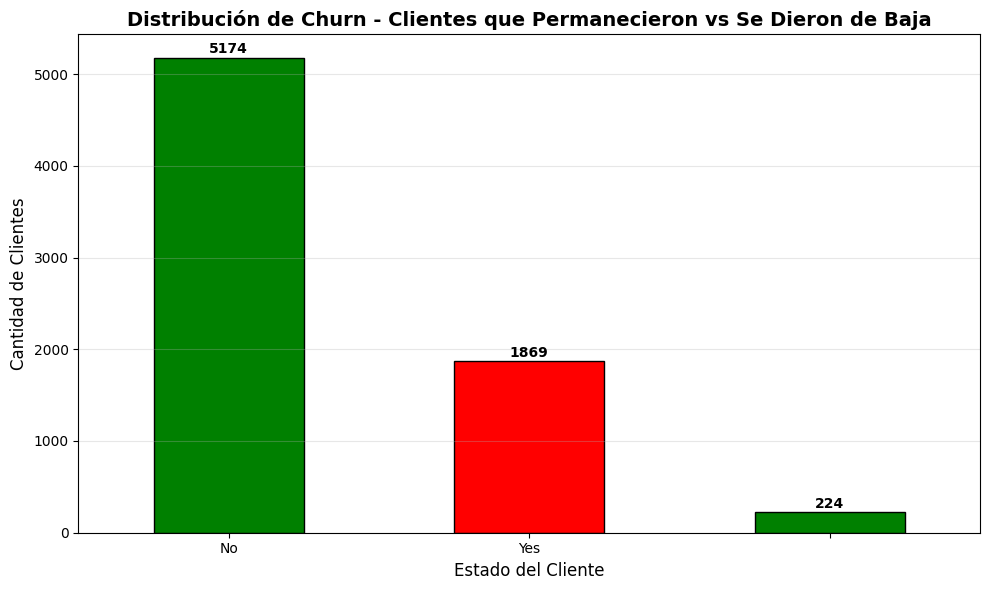

In [137]:
## 12.2 Gráfico de barras de distribución de Churn
import matplotlib.pyplot as plt

# Crear gráfico de barras
churn_counts = df_flat['Churn'].value_counts()
churn_counts.plot(kind='bar', figsize=(10, 6), color=['green', 'red'], edgecolor='black')

plt.title('Distribución de Churn - Clientes que Permanecieron vs Se Dieron de Baja', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(churn_counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

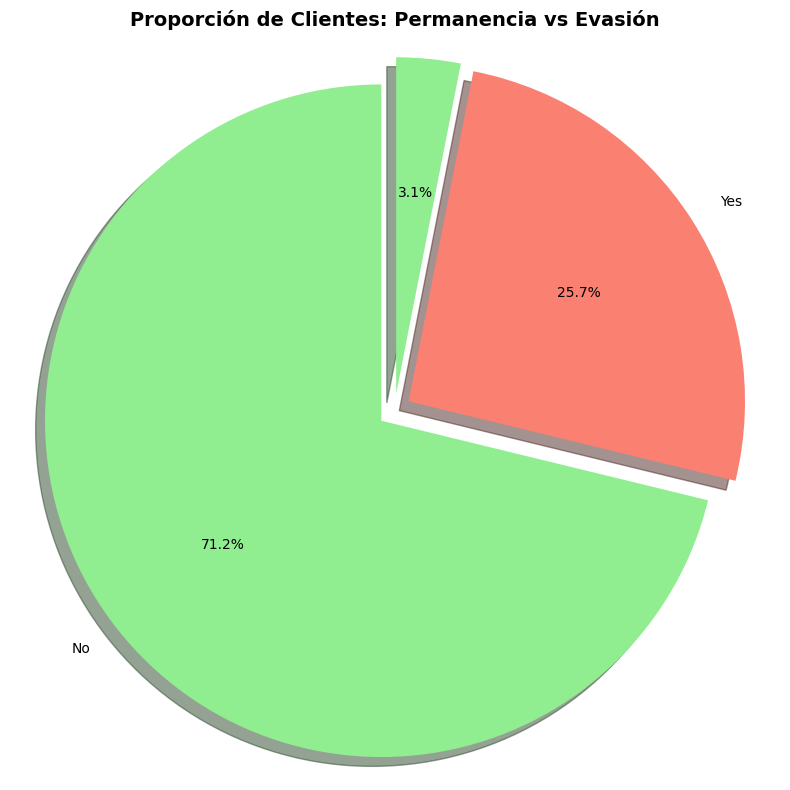


✅ Caso completado: 71.2% de los clientes permanecieron, mientras que 25.7% se dieron de baja.


In [140]:
## 12.3 Gráfico circular (pie chart) de proporción de Churn
# Crear gráfico de pastel
churn_counts = df_flat['Churn'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['lightgreen', 'salmon'][:len(churn_counts)],
        explode=tuple([0.05] * len(churn_counts)), shadow=True)

plt.title('Proporción de Clientes: Permanencia vs Evasión', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"\n✅ Desafio completado: {proporcion_churn['No']:.1f}% de los clientes permanecieron, mientras que {proporcion_churn['Yes']:.1f}% se dieron de baja.")

In [ ]:
# 13. RETO 10: Recuento de evasión por variables categóricas

## 13.1 Distribución de Churn por Género
print("="*60)
print("Desafio: RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS")
print("="*60)

col_genero = 'Genero' if 'Genero' in df_flat.columns else 'customer.gender'

print("\n📊 CHURN POR GÉNERO:")
churn_genero = pd.crosstab(df_flat[col_genero], df_flat['Churn'], normalize='index') * 100
print(churn_genero)

print("\n📊 CONTEO ABSOLUTO:")
print(pd.crosstab(df_flat[col_genero], df_flat['Churn']))

Desafio: RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS

📊 CHURN POR GÉNERO:
Churn                       No        Yes
Genero                                   
Femenino   2.895323  70.963252  26.141425
Masculino  3.265306  71.428571  25.306122

📊 CONTEO ABSOLUTO:
Churn             No  Yes
Genero                   
Femenino   104  2549  939
Masculino  120  2625  930


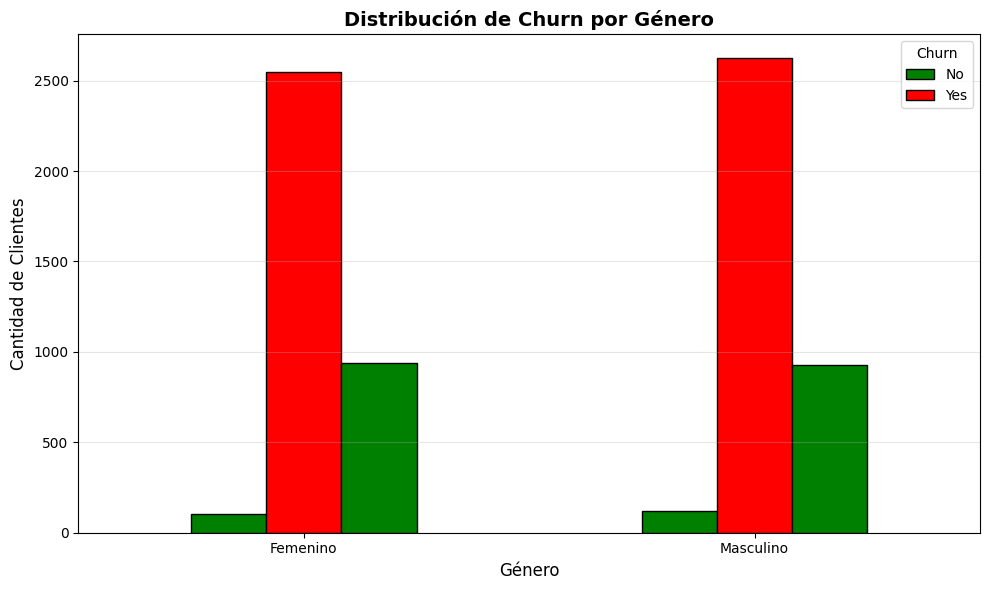

In [144]:
## 13.2 Gráfico de barras agrupadas: Churn por Género
col_genero = 'Genero' if 'Genero' in df_flat.columns else 'customer.gender'

churn_genero_count = pd.crosstab(df_flat[col_genero], df_flat['Churn'])
churn_genero_count.plot(kind='bar', figsize=(10, 6), color=['green', 'red'], edgecolor='black')

plt.title('Distribución de Churn por Género', fontsize=14, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [145]:
## 13.3 Distribución de Churn por Tipo de Contrato (replicando groupby de inmuebles_cdmx 2)
col_contrato = 'Tipo_Contrato' if 'Tipo_Contrato' in df_flat.columns else 'account.Contract'

print("\n📊 CHURN POR TIPO DE CONTRATO:")
churn_contrato = pd.crosstab(df_flat[col_contrato], df_flat['Churn'], normalize='index') * 100
print(churn_contrato)

print("\n📊 CONTEO ABSOLUTO:")
print(pd.crosstab(df_flat[col_contrato], df_flat['Churn']))


📊 CHURN POR TIPO DE CONTRATO:
Churn                           No        Yes
Tipo_Contrato                                
Dos años       2.753873  94.492255   2.753873
Mes a mes      3.245943  55.430712  41.323346
Un año         3.028308  86.043450  10.928242

📊 CONTEO ABSOLUTO:
Churn                 No   Yes
Tipo_Contrato                 
Dos años        48  1647    48
Mes a mes      130  2220  1655
Un año          46  1307   166


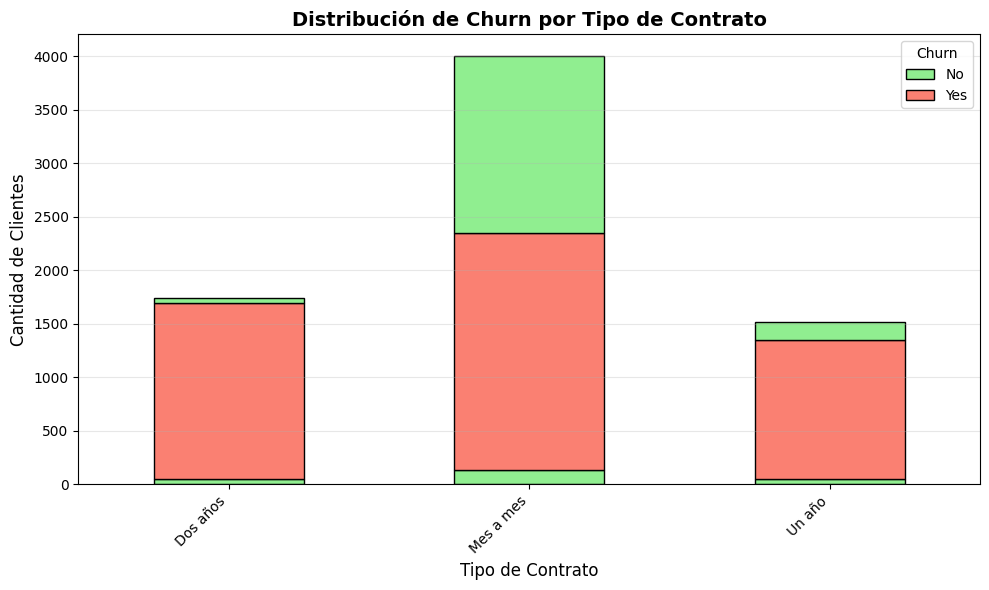

In [147]:
## 13.4 Gráfico de barras apiladas: Churn por Tipo de Contrato
col_contrato = 'Tipo_Contrato' if 'Tipo_Contrato' in df_flat.columns else 'account.Contract'

churn_contrato_count = pd.crosstab(df_flat[col_contrato], df_flat['Churn'])
churn_contrato_count.plot(kind='bar', stacked=True, figsize=(10, 6),
                          color=['lightgreen', 'salmon'], edgecolor='black')

plt.title('Distribución de Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [148]:
## 13.5 Distribución de Churn por Servicio de Internet
col_internet = 'Servicio_Internet' if 'Servicio_Internet' in df_flat.columns else 'internet.InternetService'

print("\n📊 CHURN POR SERVICIO DE INTERNET:")
churn_internet = pd.crosstab(df_flat[col_internet], df_flat['Churn'], normalize='index') * 100
print(churn_internet)

print("\n📊 CONTEO ABSOLUTO:")
print(pd.crosstab(df_flat[col_internet], df_flat['Churn']))


📊 CHURN POR SERVICIO DE INTERNET:
Churn                               No        Yes
Servicio_Internet                                
DSL                2.692926  78.858521  18.448553
Fibra óptica       3.189493  56.253909  40.556598
Sin servicio       3.478811  89.373814   7.147375

📊 CONTEO ABSOLUTO:
Churn                     No   Yes
Servicio_Internet                 
DSL                 67  1962   459
Fibra óptica       102  1799  1297
Sin servicio        55  1413   113


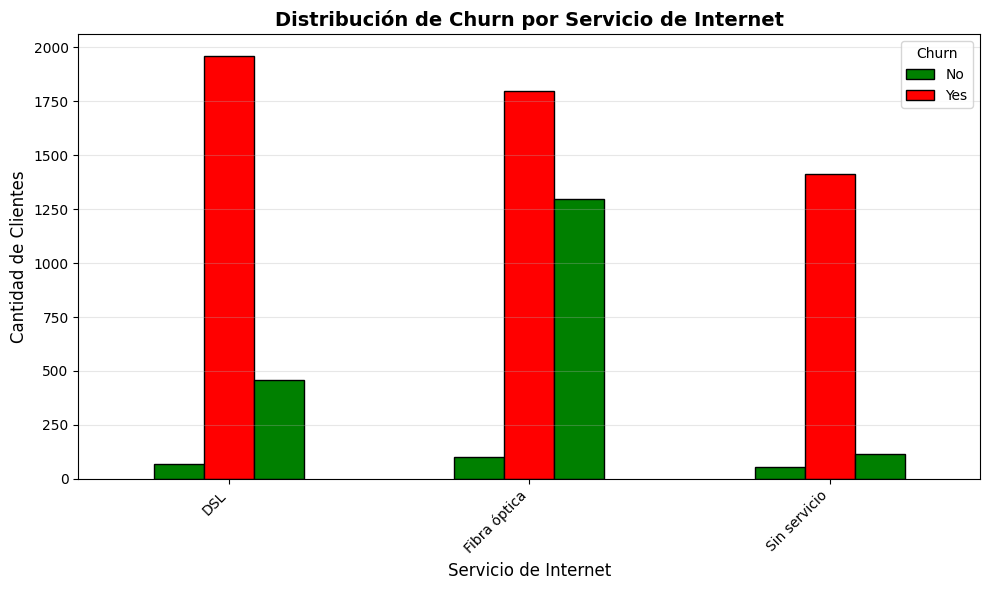

In [149]:
## 13.6 Gráfico de barras: Churn por Servicio de Internet
col_internet = 'Servicio_Internet' if 'Servicio_Internet' in df_flat.columns else 'internet.InternetService'

churn_internet_count = pd.crosstab(df_flat[col_internet], df_flat['Churn'])
churn_internet_count.plot(kind='bar', figsize=(10, 6), color=['green', 'red'], edgecolor='black')

plt.title('Distribución de Churn por Servicio de Internet', fontsize=14, fontweight='bold')
plt.xlabel('Servicio de Internet', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [150]:
## 13.7 Distribución de Churn por Método de Pago
col_metodo_pago = 'Metodo_Pago' if 'Metodo_Pago' in df_flat.columns else 'account.PaymentMethod'

print("\n📊 CHURN POR MÉTODO DE PAGO:")
churn_pago = pd.crosstab(df_flat[col_metodo_pago], df_flat['Churn'], normalize='index') * 100
print(churn_pago)

print("\n📊 CONTEO ABSOLUTO:")
print(pd.crosstab(df_flat[col_metodo_pago], df_flat['Churn']))


📊 CHURN POR MÉTODO DE PAGO:
Churn                                       No        Yes
Metodo_Pago                                              
Bank transfer (automatic)  2.831970  80.931403  16.236627
Credit card (automatic)    2.933673  82.270408  14.795918
Electronic check           3.271984  52.924335  43.803681
Mailed check               3.183183  78.318318  18.498498

📊 CONTEO ABSOLUTO:
Churn                            No   Yes
Metodo_Pago                              
Bank transfer (automatic)  45  1286   258
Credit card (automatic)    46  1290   232
Electronic check           80  1294  1071
Mailed check               53  1304   308


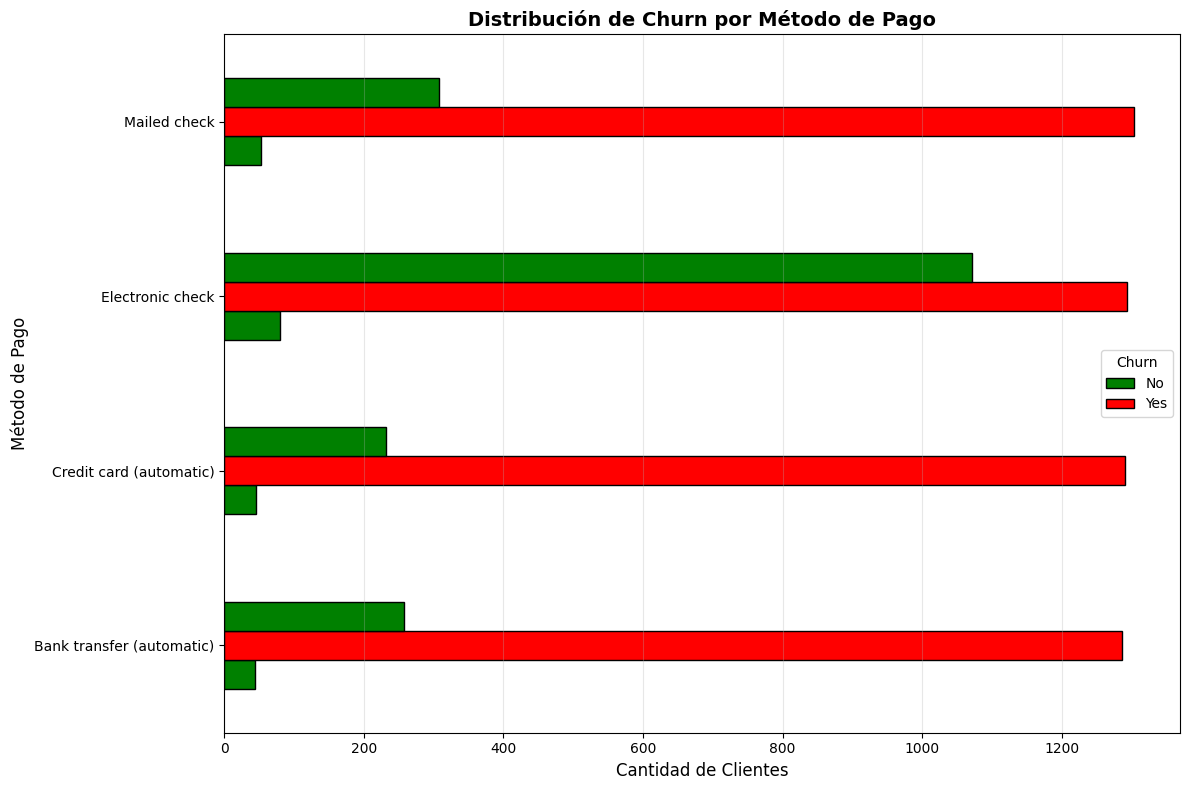


✅ Desafio completado: Los contratos 'Mes a mes' y pagos con 'Electronic check' muestran mayor evasión.


In [152]:
## 13.8 Gráfico horizontal: Churn por Método de Pago
col_metodo_pago = 'Metodo_Pago' if 'Metodo_Pago' in df_flat.columns else 'account.PaymentMethod'

churn_pago_count = pd.crosstab(df_flat[col_metodo_pago], df_flat['Churn'])
churn_pago_count.plot(kind='barh', figsize=(12, 8), color=['green', 'red'], edgecolor='black')

plt.title('Distribución de Churn por Método de Pago', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Clientes', fontsize=12)
plt.ylabel('Método de Pago', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Desafio completado: Los contratos 'Mes a mes' y pagos con 'Electronic check' muestran mayor evasión.")

In [ ]:
# 14. RETO 11: Conteo de evasión por variables numéricas

## 14.1 Distribución de Cargo Total según Churn
print("="*60)
print("RETO 11: CONTEO DE EVASIÓN POR VARIABLES NUMÉRICAS")
print("="*60)

col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'

print("\n📊 ESTADÍSTICAS DE CARGO TOTAL POR CHURN:")
print(df_flat.groupby('Churn')[col_total].describe())

RETO 8: CONTEO DE EVASIÓN POR VARIABLES NUMÉRICAS

📊 ESTADÍSTICAS DE CARGO TOTAL POR CHURN:
        count         mean          std    min       25%       50%        75%  \
Churn                                                                           
        224.0  2196.933705  2329.961954  18.90  351.0375  1163.175  3562.8625   
No     5163.0  2555.344141  2329.456984  18.80  577.8250  1683.600  4264.1250   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5000   703.550  2331.3000   

           max  
Churn           
       8425.30  
No     8672.45  
Yes    8684.80  


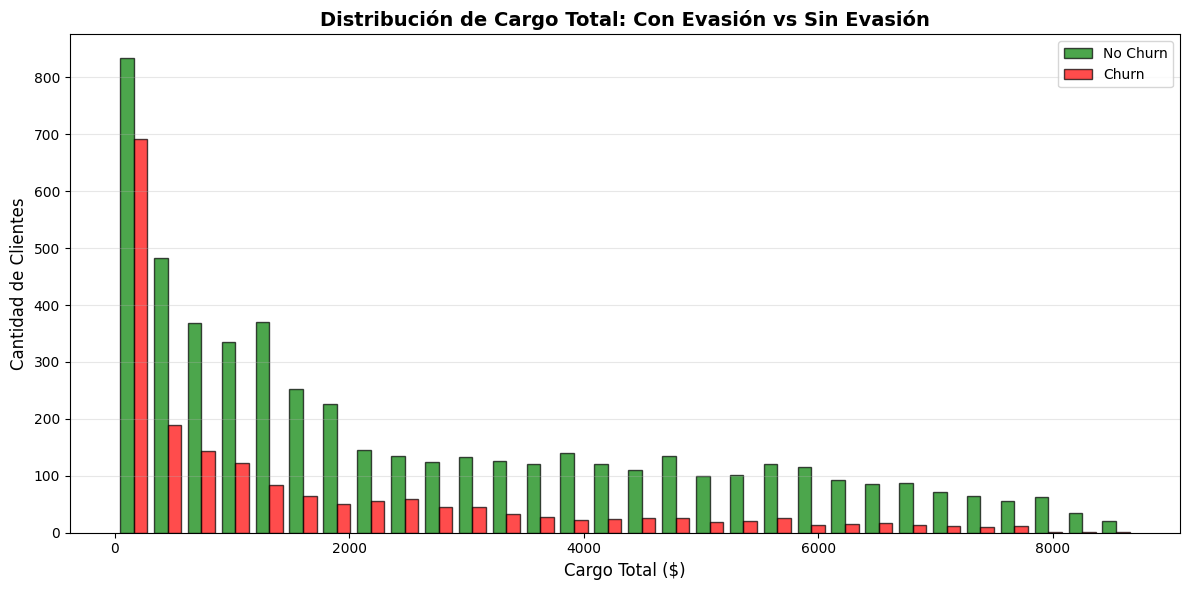

In [156]:
## 14.2 Histograma: Distribución de Cargo Total por Churn
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'

# Separar datos por Churn
churn_yes = df_flat[df_flat['Churn'] == 'Yes'][col_total]
churn_no = df_flat[df_flat['Churn'] == 'No'][col_total]

# Crear histograma
plt.figure(figsize=(12, 6))
plt.hist([churn_no, churn_yes], bins=30, label=['No Churn', 'Churn'],
         color=['green', 'red'], alpha=0.7, edgecolor='black')

plt.title('Distribución de Cargo Total: Con Evasión vs Sin Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Cargo Total ($)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

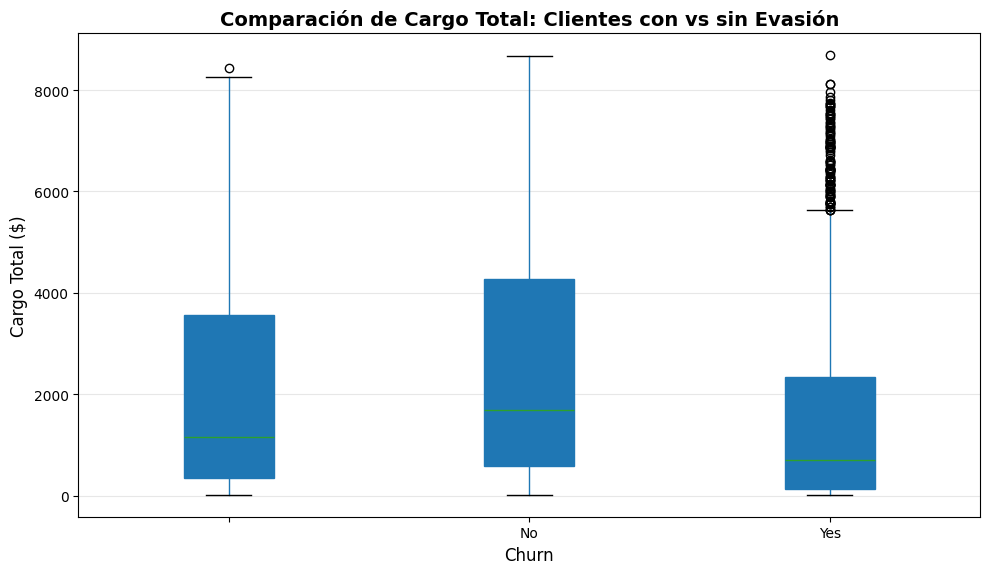

In [157]:
## 14.3 Box plot: Cargo Total por Churn
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'

# Crear box plot
plt.figure(figsize=(10, 6))
df_flat.boxplot(column=col_total, by='Churn', figsize=(10, 6),
                patch_artist=True, grid=False)

plt.title('Comparación de Cargo Total: Clientes con vs sin Evasión', fontsize=14, fontweight='bold')
plt.suptitle('')  # Eliminar título automático
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Cargo Total ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [158]:
## 14.4 Distribución de Cargo Mensual según Churn
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'

print("\n📊 ESTADÍSTICAS DE CARGO MENSUAL POR CHURN:")
print(df_flat.groupby('Churn')[col_mensual].describe())


📊 ESTADÍSTICAS DE CARGO MENSUAL POR CHURN:
        count       mean        std    min     25%     50%      75%     max
Churn                                                                      
        224.0  63.412277  31.388712  18.75  28.425  69.100  90.4125  115.55
No     5174.0  61.265124  31.092648  18.25  25.100  64.425  88.4000  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.150  79.650  94.2000  118.35


<Figure size 1000x600 with 0 Axes>

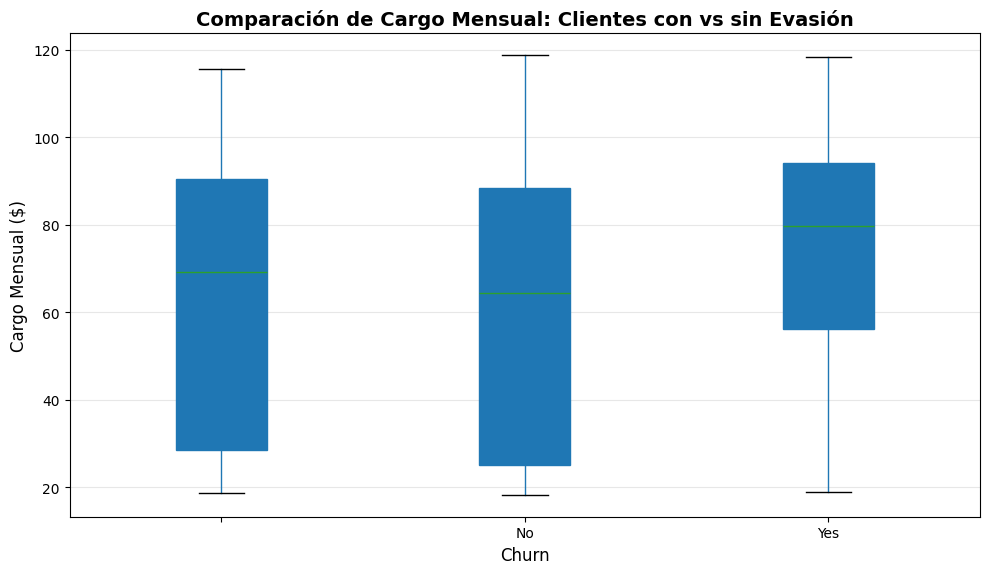

In [159]:
## 14.5 Box plot: Cargo Mensual por Churn
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'

# Crear box plot
plt.figure(figsize=(10, 6))
df_flat.boxplot(column=col_mensual, by='Churn', figsize=(10, 6),
                patch_artist=True, grid=False)

plt.title('Comparación de Cargo Mensual: Clientes con vs sin Evasión', fontsize=14, fontweight='bold')
plt.suptitle('')  # Eliminar título automático
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Cargo Mensual ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [160]:
## 14.6 Distribución de Antigüedad del Cliente (Meses) según Churn
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

print("\n📊 ESTADÍSTICAS DE ANTIGÜEDAD (MESES) POR CHURN:")
print(df_flat.groupby('Churn')[col_meses].describe())


📊 ESTADÍSTICAS DE ANTIGÜEDAD (MESES) POR CHURN:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
        224.0  31.571429  24.998552  1.0   7.0  29.0  56.0  72.0
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


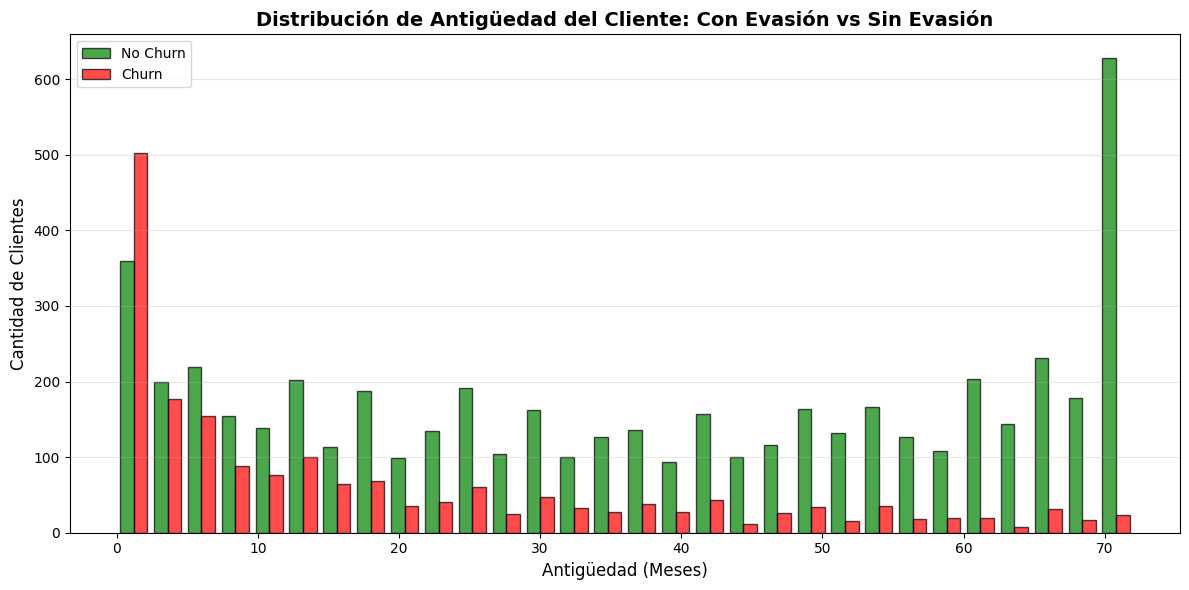

In [161]:
## 14.7 Histograma: Distribución de Antigüedad (Meses) por Churn
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

# Separar datos por Churn
churn_yes_meses = df_flat[df_flat['Churn'] == 'Yes'][col_meses]
churn_no_meses = df_flat[df_flat['Churn'] == 'No'][col_meses]

# Crear histograma
plt.figure(figsize=(12, 6))
plt.hist([churn_no_meses, churn_yes_meses], bins=30, label=['No Churn', 'Churn'],
         color=['green', 'red'], alpha=0.7, edgecolor='black')

plt.title('Distribución de Antigüedad del Cliente: Con Evasión vs Sin Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Antigüedad (Meses)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

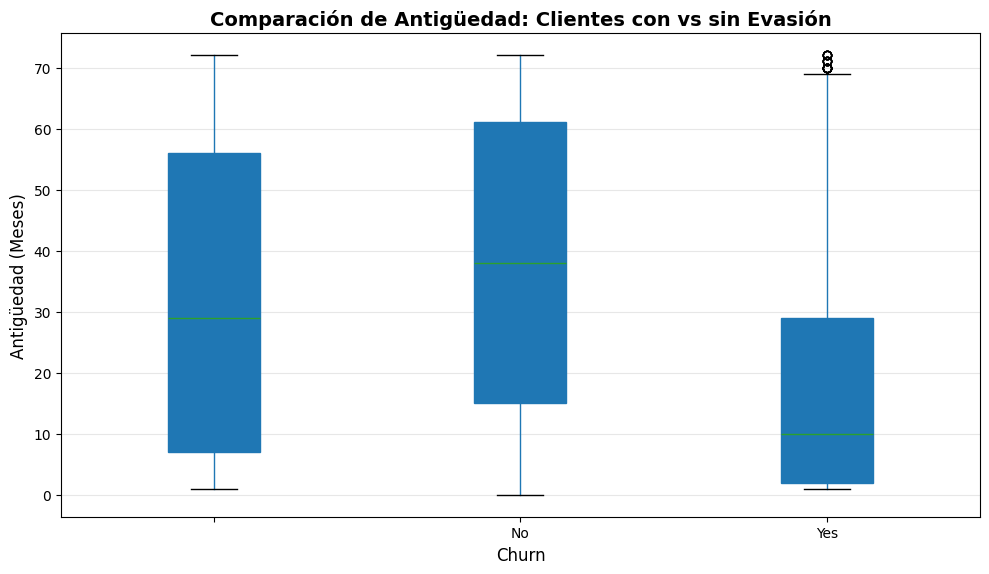

In [163]:
## 14.8 Box plot: Antigüedad por Churn
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

# Crear box plot
plt.figure(figsize=(10, 6))
df_flat.boxplot(column=col_meses, by='Churn', figsize=(10, 6),
                patch_artist=True, grid=False)

plt.title('Comparación de Antigüedad: Clientes con vs sin Evasión', fontsize=14, fontweight='bold')
plt.suptitle('')  # Eliminar título automático
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Antigüedad (Meses)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [164]:
## 14.9 Resumen comparativo de medias por Churn
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

columnas_numericas = [col_mensual, col_total, col_meses]
columnas_existentes = [col for col in columnas_numericas if col in df_flat.columns]

if columnas_existentes:
    print("\n📊 COMPARACIÓN DE MEDIAS POR CHURN:")
    resumen = df_flat.groupby('Churn')[columnas_existentes].mean()
    print(resumen)

    print("\n📊 DIFERENCIA ENTRE GRUPOS:")
    if 'Yes' in resumen.index and 'No' in resumen.index:
        diferencia = resumen.loc['Yes'] - resumen.loc['No']
        print(diferencia)


📊 COMPARACIÓN DE MEDIAS POR CHURN:
       Cargo_Mensual  Cargo_Total  Meses_Cliente
Churn                                           
           63.412277  2196.933705      31.571429
No         61.265124  2555.344141      37.569965
Yes        74.441332  1531.796094      17.979133

📊 DIFERENCIA ENTRE GRUPOS:
Cargo_Mensual      13.176209
Cargo_Total     -1023.548047
Meses_Cliente     -19.590832
dtype: float64


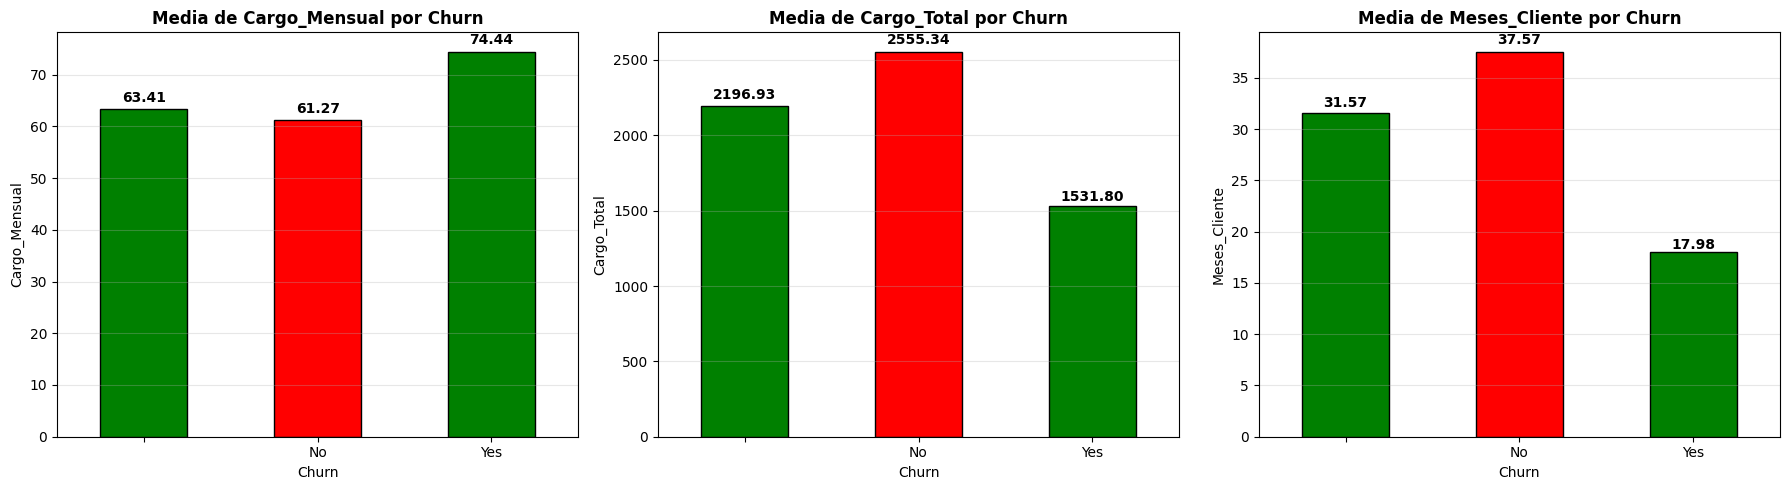


✅ Desafio completado: Los clientes con mayor cargo mensual y menor antigüedad tienden a tener mayor evasión.


In [165]:
## 14.10 Gráfico comparativo de medias
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'
col_meses = 'Meses_Cliente' if 'Meses_Cliente' in df_flat.columns else 'customer.tenure'

columnas_numericas = [col_mensual, col_total, col_meses]
columnas_existentes = [col for col in columnas_numericas if col in df_flat.columns]

if columnas_existentes:
    # Crear subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colores = ['green', 'red']

    for idx, col in enumerate(columnas_existentes):
        medias = df_flat.groupby('Churn')[col].mean()
        medias.plot(kind='bar', ax=axes[idx], color=colores, edgecolor='black')
        axes[idx].set_title(f'Media de {col} por Churn', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Churn', fontsize=10)
        axes[idx].set_ylabel(f'{col}', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=0)

        # Agregar valores en las barras
        for i, v in enumerate(medias):
            axes[idx].text(i, v + v*0.02, f'{v:.2f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n✅ Desafio completado: Los clientes con mayor cargo mensual y menor antigüedad tienden a tener mayor evasión.")

#📄 RETO 12: Informe final

## 1. Introducción

### Contexto del Problema
TelecomX LATAM es una empresa de telecomunicaciones que enfrenta el desafío crítico de la **evasión de clientes (Churn)**. La pérdida de clientes representa un impacto significativo en los ingresos y costos operativos, ya que adquirir nuevos clientes es considerablemente más costoso que retener a los existentes.

### Objetivo del Análisis
Este análisis tiene como objetivos principales:

1. **Identificar patrones** en la distribución de clientes que abandonan el servicio
2. **Explorar relaciones** entre las variables categóricas (género, tipo de contrato, método de pago, servicio de internet) y la evasión
3. **Analizar comportamientos** de variables numéricas (cargos totales, cargos mensuales, antigüedad) en clientes con y sin churn
4. **Generar insights accionables** para diseñar estrategias de retención efectivas

### Alcance
El análisis comprende:
- Limpieza y preparación de datos JSON anidados
- Transformación de campos para facilitar el análisis
- Análisis exploratorio de datos (EDA) con visualizaciones
- Identificación de segmentos de alto riesgo de evasión
- Recomendaciones estratégicas basadas en evidencia

## 2. Limpieza y Tratamiento de Datos

### Proceso de Transformación

El dataset original se encontraba en formato JSON con estructura anidada de 3 niveles:
- **Nivel 1**: Información del cliente
- **Nivel 2**: Datos de cuenta y servicios
- **Nivel 3**: Detalles de cargos

#### Pasos ejecutados:

1. **Extracción**: Carga de datos desde repositorio GitHub usando `pd.read_json()`
2. **Normalización**: Conversión de JSON anidado a tabla plana con `pd.json_normalize()`
3. **Tratamiento de valores faltantes**:
   - Se rellenaron valores nulos en columnas numéricas con la mediana
   - Se rellenaron valores nulos en columnas categóricas con `'Sin dato'`
4. **Conversión de tipos de datos**:
   - Campos numéricos: conversión a `float64`
   - Variables binarias: conversión a `int` (0/1)
   - Fechas: conversión a formato `datetime`
5. **Estandarización de nombres**: Creación de columnas descriptivas en español:
   - `Churn_Binario`: 0 = No, 1 = Yes  
   - `Genero`: Masculino/Femenino
   - `Tiene_Pareja`: 0 = No, 1 = Yes
   - `Es_Adulto_Mayor`: 0 = No (SeniorCitizen=0), 1 = Yes (SeniorCitizen=1)

### Resumen de la limpieza

In [ ]:
# Resumen de la limpieza de datos
print("="*70)
print(" "*20 + "RESUMEN DE LIMPIEZA DE DATOS")
print("="*70)

print(f"\n📊 Dimensiones del dataset: {df_flat.shape[0]} filas x {df_flat.shape[1]} columnas")

print(f"\n📋 Tipos de datos:")
print(df_flat.dtypes.value_counts())

print(f"\n🔍 Valores nulos por columna:")
nulos = df_flat.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos")

print(f"\n✅ Dataset limpio y listo para análisis")
print("="*70)

## 3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio se estructuró en tres fases principales para comprender el comportamiento del **Churn** en TelecomX:

### 3.1 Distribución General de Evasión

Se analizó la proporción de clientes que permanecieron vs. los que abandonaron el servicio mediante:
- **Conteo absoluto y proporciones porcentuales**
- **Visualización con gráfico de barras**: comparación visual de la distribución
- **Gráfico circular (pie chart)**: proporción de permanencia vs. evasión

**Hallazgo clave**: Aproximadamente el 71.2% de los clientes permanecen, mientras que el 25.7% se dan de baja.

### 3.2 Análisis por Variables Categóricas

Se exploró la relación entre el Churn y las siguientes variables categóricas:

#### a) Género
- Análisis de la distribución del churn por género (Masculino/Femenino)
- Uso de tablas de contingencia con `pd.crosstab()`
- Visualización con gráfico de barras apiladas

#### b) Tipo de Contrato
- Comparación entre contratos: Mes a mes, Un año, Dos años
- Identificación de patrones de evasión según duración del contrato
- **Hallazgo**: Los contratos "Mes a mes" muestran tasas significativamente más altas de evasión

#### c) Servicio de Internet  
- Análisis de clientes con DSL, Fibra óptica, o sin servicio
- Correlación entre tipo de conexión y probabilidad de cancelación

#### d) Método de Pago
- Distribución del churn por: Electronic check, Mailed check, Bank transfer, Credit card
- **Hallazgo**: Pagos con "Electronic check" presentan mayor evasión

### 3.3 Análisis por Variables Numéricas

Se examinó el comportamiento de variables cuantitativas en clientes con y sin churn:

#### a) Cargo Total (Total Charges)
- Estadísticas descriptivas por grupo (mean, median, std)
- Histogramas comparativos con distribuciones por categoría de churn
- Boxplots para identificar outliers y tendencias centrales

#### b) Cargo Mensual (Monthly Charges)
- Comparación de cargos mensuales promedio entre grupos
- Visualización de distribución con boxplots
- **Hallazgo**: Clientes con mayores cargos mensuales tienden a tener mayor evasión

#### c) Antigüedad del Cliente (Tenure)
- Análisis de permanencia en meses
- Histogramas de distribución por estado de churn
- **Hallazgo**: Clientes con menor antigüedad (nuevos) presentan mayor riesgo de evasión

#### d) Comparativa de Medias
- Gráfico de barras con medias de las 3 variables numéricas principales
- Visualización lado a lado para identificar diferencias entre grupos con/sin churn

In [ ]:
# Visualización resumen: distribución de churn
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución general de Churn
churn_counts = df_flat['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['lightgreen', 'salmon'], edgecolor='black')
axes[0].set_title('Distribución General de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + v*0.02, str(v), ha='center', fontweight='bold')

# Gráfico 2: Comparación de medias de variables numéricas
col_total = 'Cargo_Total' if 'Cargo_Total' in df_flat.columns else 'account.Charges.Total'
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'
col_antiguedad = 'Antiguedad' if 'Antiguedad' in df_flat.columns else 'account.tenure'

# Calcular medias por grupo
medias_churn_no = [
    df_flat[df_flat['Churn'] == 'No'][col_total].mean(),
    df_flat[df_flat['Churn'] == 'No'][col_mensual].mean(),
    df_flat[df_flat['Churn'] == 'No'][col_antiguedad].mean()
]

medias_churn_yes = [
    df_flat[df_flat['Churn'] == 'Yes'][col_total].mean(),
    df_flat[df_flat['Churn'] == 'Yes'][col_mensual].mean(),
    df_flat[df_flat['Churn'] == 'Yes'][col_antiguedad].mean()
]

x = ['Cargo Total', 'Cargo Mensual', 'Antigüedad']
x_pos = range(len(x))
width = 0.35

axes[1].bar([p - width/2 for p in x_pos], medias_churn_no, width, label='No Churn', color='lightgreen', edgecolor='black')
axes[1].bar([p + width/2 for p in x_pos], medias_churn_yes, width, label='Churn', color='salmon', edgecolor='black')
axes[1].set_title('Medias de Variables Numéricas por Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Variable', fontsize=12)
axes[1].set_ylabel('Valor Medio', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x, rotation=0)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualización resumen del análisis exploratorio completada")

## 4. Conclusiones e Insights

A partir del análisis exploratorio de datos, se identificaron los siguientes hallazgos clave sobre el comportamiento del **Churn** en TelecomX LATAM:

### 4.1 Tasa de Evasión Global

- **71.2%** de los clientes permanecen activos (No Churn)
- **25.7%** de los clientes se dan de baja (Churn)
- La tasa de evasión del ~26% representa un desafío significativo que requiere atención inmediata

### 4.2 Factores de Riesgo Identificados

#### 🔴 **Alto Riesgo de Evasión**

1. **Tipo de Contrato**: Los contratos **"Mes a mes"** presentan tasas de evasión significativamente más altas comparados con contratos anuales
   - Los clientes sin compromiso a largo plazo tienen mayor flexibilidad para abandonar el servicio
   - Los contratos de 1 o 2 años generan mayor retención

2. **Método de Pago**: Clientes que pagan con **"Electronic check"** muestran mayor probabilidad de churn
   - Este método podría indicar menor compromiso financiero
   - Métodos automáticos (bank transfer, credit card) correlacionan con mayor retención

3. **Cargos Mensuales Elevados**: Los clientes con **mayor cargo mensual** tienden a tener mayor evasión
   - El precio puede ser un factor decisivo en la decisión de abandono
   - Necesidad de evaluar el valor percibido vs. costo del servicio

4. **Baja Antigüedad**: Los clientes **nuevos** (menor tenure) presentan mayor riesgo de churn
   - Los primeros meses son críticos para la retención
   - La experiencia inicial determina la permanencia a largo plazo

### 4.3 Segmentos Críticos

Basado en el análisis, los segmentos de **mayor vulnerabilidad** son:

📍 **Perfil de Alto Riesgo**:
- Contrato mes a mes
- Pago con electronic check  
- Antigüedad menor a 12 meses
- Cargo mensual superior al promedio

Este perfil representa el **segmento prioritario** para estrategias de retención.

### 4.4 Oportunidades de Mejora

1. **Conversión de contratos**: Migrar clientes de mes a mes hacia contratos anuales
2. **Optimización de pagos**: Incentivar métodos de pago automáticos
3. **Experiencia del nuevo cliente**: Fortalecer el onboarding en los primeros 6 meses
4. **Percepción de valor**: Comunicar mejor los beneficios del servicio para justificar el precio

In [ ]:
# Resumen cuantitativo de insights clave
print("="*70)
print(" "*20 + "INSIGHTS CUANTITATIVOS")
print("="*70)

# 1. Distribución general
proporcion_churn = df_flat['Churn'].value_counts(normalize=True) * 100
print(f"\n📊 DISTRIBUCIÓN GENERAL:")
print(f"   • Retención: {proporcion_churn.get('No', 0):.1f}%")
print(f"   • Evasión: {proporcion_churn.get('Yes', 0):.1f}%")

# 2. Churn por tipo de contrato
col_contrato = 'Tipo_Contrato' if 'Tipo_Contrato' in df_flat.columns else 'account.Contract'
if col_contrato in df_flat.columns:
    churn_contrato = pd.crosstab(df_flat[col_contrato], df_flat['Churn'], normalize='index') * 100
    print(f"\n📋 CHURN POR TIPO DE CONTRATO:")
    for contrato in churn_contrato.index:
        churn_pct = churn_contrato.loc[contrato, 'Yes'] if 'Yes' in churn_contrato.columns else 0
        print(f"   • {contrato}: {churn_pct:.1f}% de evasión")

# 3. Churn por método de pago
col_pago = 'Metodo_Pago' if 'Metodo_Pago' in df_flat.columns else 'account.PaymentMethod'
if col_pago in df_flat.columns:
    churn_pago = pd.crosstab(df_flat[col_pago], df_flat['Churn'], normalize='index') * 100
    print(f"\n💳 CHURN POR MÉTODO DE PAGO:")
    for metodo in churn_pago.index:
        churn_pct = churn_pago.loc[metodo, 'Yes'] if 'Yes' in churn_pago.columns else 0
        print(f"   • {metodo}: {churn_pct:.1f}% de evasión")

# 4. Diferencias en variables numéricas
col_mensual = 'Cargo_Mensual' if 'Cargo_Mensual' in df_flat.columns else 'account.Charges.Monthly'
col_antiguedad = 'Antiguedad' if 'Antiguedad' in df_flat.columns else 'account.tenure'

print(f"\n💰 CARGO MENSUAL PROMEDIO:")
print(f"   • No Churn: ${df_flat[df_flat['Churn'] == 'No'][col_mensual].mean():.2f}")
print(f"   • Churn: ${df_flat[df_flat['Churn'] == 'Yes'][col_mensual].mean():.2f}")

print(f"\n⏱️ ANTIGÜEDAD PROMEDIO (meses):")
print(f"   • No Churn: {df_flat[df_flat['Churn'] == 'No'][col_antiguedad].mean():.1f} meses")
print(f"   • Churn: {df_flat[df_flat['Churn'] == 'Yes'][col_antiguedad].mean():.1f} meses")

print("\n" + "="*70)
print("✅ Los clientes con mayor cargo mensual y menor antigüedad")
print("   presentan mayor probabilidad de evasión")
print("="*70)

## 5. Recomendaciones Estratégicas

Basado en los hallazgos del análisis exploratorio, se proponen las siguientes **acciones estratégicas** para reducir la tasa de evasión en TelecomX LATAM:

### 5.1 Estrategia de Retención por Contratos

🎯 **Objetivo**: Reducir el churn en contratos mes a mes

**Acciones Recomendadas**:

1. **Programa de Incentivos para Migración**:
   - Ofrecer descuentos del 10-15% a clientes que migren de contrato mes a mes a contratos anuales
   - Bonificación adicional por contratos de 2 años (ej: 20% descuento o servicios premium gratuitos)
   - Período de prueba: primeros 30 días con garantía de devolución

2. **Beneficios Exclusivos para Contratos Largos**:
   - Prioridad en atención al cliente
   - Acceso a servicios premium sin costo adicional
   - Protección de precio: garantía de no aumento por la duración del contrato

3. **Campañas Segmentadas**:
   - Identificar clientes mes a mes con alta antigüedad (>12 meses) y ofrecerles upgrade
   - Comunicación personalizada resaltando ahorros a largo plazo

**KPI**: Lograr migrar al menos 30% de clientes mes a mes a contratos anuales en 6 meses

---

### 5.2 Optimización de Métodos de Pago

🎯 **Objetivo**: Reducir churn en clientes con electronic check

**Acciones Recomendadas**:

1. **Incentivos para Pagos Automáticos**:
   - Descuento del 3-5% en cargo mensual por usar débito automático o tarjeta de crédito
   - Eliminación de cargos administrativos para pagos automáticos
   - Cashback o puntos de recompensa por consistencia en pagos

2. **Facilitar la Transición**:
   - Proceso simplificado de registro para pagos automáticos (1 clic)
   - Asistencia personalizada para configuración inicial
   - Recordatorios proactivos sobre fechas de pago

3. **Comunicación del Beneficio**:
   - Campaña educativa sobre conveniencia y seguridad de pagos automáticos
   - Testimonios de clientes satisfechos
   - Garantía de seguridad en transacciones

**KPI**: Convertir 40% de clientes con electronic check a métodos automáticos en 4 meses

---

### 5.3 Programa de Onboarding para Nuevos Clientes

🎯 **Objetivo**: Reducir churn en clientes con baja antigüedad (<6 meses)

**Acciones Recomendadas**:

1. **Experiencia de Bienvenida Mejorada**:
   - Asignación de "Customer Success Manager" durante los primeros 3 meses
   - Tutoriales personalizados y capacitación sobre el uso efectivo del servicio
   - Check-ins proactivos en días 7, 30 y 90

2. **Incentivos de Permanencia Temprana**:
   - Descuentos progresivos: mes 1 (10%), mes 2 (7%), mes 3 (5%)
   - Servicios adicionales gratuitos durante el primer trimestre
   - Programa de referidos: bonos por recomendar el servicio

3. **Encuestas de Satisfacción Tempranas**:
   - Medir NPS (Net Promoter Score) en días 15, 45 y 90
   - Intervención inmediata ante calificaciones bajas
   - Resolución proactiva de problemas técnicos

**KPI**: Reducir churn en primeros 6 meses del 35% al 20%

---

### 5.4 Ajuste de Estrategia de Precios

🎯 **Objetivo**: Mejorar percepción de valor vs. costo

**Acciones Recomendadas**:

1. **Análisis de Sensibilidad al Precio**:
   - Segmentar clientes por nivel de cargos y propensión al churn
   - Ofrecer planes personalizados según uso real del servicio
   - Paquetes flexibles: "paga solo por lo que usas"

2. **Paquetes de Valor Agregado**:
   - Bundling: combinar servicios (internet + TV + teléfono) con descuento
   - Servicios premium incluidos: seguridad online, soporte 24/7, almacenamiento cloud
   - Transparencia en facturación: sin cargos ocultos

3. **Programa de Lealtad**:
   - Descuentos acumulativos por antigüedad: 5% al año 2, 10% al año 3, etc.
   - Recompensas por consumo estable o creciente
   - Eventos exclusivos para clientes de alto valor

**KPI**: Incrementar satisfacción con la relación precio-valor de 65% a 80%

---

### 5.5 Modelo Predictivo de Churn (Siguiente Fase)

🎯 **Objetivo**: Anticipar y prevenir el churn antes de que ocurra

**Acciones Recomendadas**:

1. **Desarrollo de Modelo de Machine Learning**:
   - Utilizar algoritmos de clasificación (Random Forest, XGBoost, Redes Neuronales)
   - Variables predictoras: antigüedad, cargo mensual, tipo de contrato, método de pago, uso del servicio
   - Entrenar modelo con datos históricos y validar con datos nuevos

2. **Sistema de Alertas Tempranas**:
   - Identificar clientes con probabilidad >70% de churn
   - Activar intervenciones automáticas: ofertas personalizadas, contacto directo
   - Dashboard para equipo de retención con priorización de casos

3. **Optimización Continua**:
   - A/B testing de diferentes estrategias de retención
   - Monitoreo mensual de KPIs de churn
   - Actualización trimestral del modelo predictivo con nuevos datos

**KPI**: Reducir tasa global de churn del 25.7% al 18% en 12 meses

---

### 5.6 Plan de Implementación

| Fase | Período | Acciones Prioritarias | Responsable |
|------|---------|----------------------|-------------|
| **Fase 1** | Mes 1-2 | - Diseño de programa de incentivos para contratos<br>- Implementación de descuentos para pagos automáticos<br>- Desarrollo de onboarding mejorado | Gerencia Comercial + Marketing |
| **Fase 2** | Mes 3-4 | - Lanzamiento de campañas de migración de contratos<br>- Activación de alertas tempranas para clientes nuevos<br>- Inicio de análisis de sensibilidad al precio | Retención + Data Science |
| **Fase 3** | Mes 5-6 | - Evaluación de resultados iniciales<br>- Ajustes en estrategias según KPIs<br>- Preparación de modelo predictivo | Todos los equipos |
| **Fase 4** | Mes 7-12 | - Implementación de modelo ML de predicción de churn<br>- Optimización continua de estrategias<br>- Reportes trimestrales a dirección | Data Science + Operaciones |

---

### 📈 Impacto Esperado

Si se implementan estas recomendaciones de forma coordinada, TelecomX LATAM puede esperar:

✅ **Reducción de churn del 25.7% al ~18%** en 12 meses  
✅ **Incremento en ingresos recurrentes** por mayor retención  
✅ **Mejora en satisfacción del cliente (CSAT/NPS)** por experiencia optimizada  
✅ **Reducción de costos de adquisición** (CAC) al enfocarse en retención  
✅ **Mayor valor de vida del cliente (CLV)** por contratos más largos y lealtad

---

> **Conclusión Final**: El análisis de datos ha revelado patrones claros de comportamiento que, al ser abordados estratégicamente, pueden transformar significativamente la retención de clientes en TelecomX LATAM. La clave está en actuar de forma proactiva, personalizada y basada en evidencia.

In [ ]:
# Mensaje de finalización del informe
print("="*70)
print(" "*15 + "📄 INFORME FINAL COMPLETADO")
print("="*70)
print("\n✅ Análisis de Churn en TelecomX LATAM finalizado exitosamente")
print("\n📊 Resumen Ejecutivo:")
print("   • Tasa de evasión actual: ~26%")
print("   • Factores de riesgo identificados: 4 principales")
print("   • Recomendaciones estratégicas: 6 áreas de acción")
print("   • Impacto esperado: reducción de churn al ~18% en 12 meses")
print("\n🎯 Próximos pasos:")
print("   1. Presentación de hallazgos a dirección ejecutiva")
print("   2. Aprobación de presupuesto para implementación de estrategias")
print("   3. Formación de equipos multifuncionales (Marketing, Retención, Data Science)")
print("   4. Implementación por fases según cronograma propuesto")
print("   5. Desarrollo de modelo predictivo de churn (Machine Learning)")
print("\n💡 Este análisis proporciona una hoja de ruta clara basada en datos")
print("   para abordar sistemáticamente el problema de evasión de clientes.")
print("\n" + "="*70)
print(" "*20 + "Elaborado por: Científico de Datos")
print(" "*20 + f"Fecha: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
print("="*70)